# Ford × FIAP 2026 — Desafio 02: Impulsionando o VIN Share na América do Sul
## Sprint 3 — Inteligência Artificial & Machine Learning

**Integrantes:**
* Lucca Borges — RM 554608
* Ruan Melo — RM 557599
* Rodrigo Jimenez — RM 558148
* João Victor Franco — RM 556790
* Bruno Leão — RM 555563

---

**Solução proposta:** um modelo de *Machine Learning* que, **no momento da compra do veículo**, estima a probabilidade de o cliente **sair da rede de concessionárias Ford (churn) nos 24 meses seguintes**. Com esse *score* a concessionária recebe **leads priorizados** e pode agir antes de o cliente migrar para uma oficina independente, o que pode ajudar a preservar o **VIN Share** (percentual de veículos Ford que fazem manutenção na rede oficial).

**Resultado em uma frase:** usando só as 22 informações disponíveis no momento da venda, o modelo selecionado (**XGBoost ajustado**) coloca **43,7 % de todos os clientes que vão sair da rede entre os 20 % de maior risco** (2,19× melhor que o acaso). A faixa de risco **Alto** (10 % dos clientes) tem taxa de churn de **35,4 %**, 2,5× a média de 14,2 %. No teste, a PR-AUC foi **0,301** (acaso = 0,142) e a ROC-AUC **0,738**.

O notebook segue exatamente as etapas pedidas no enunciado da disciplina:

| Etapa do enunciado | Peso | Seção deste notebook |
|---|---|---|
| 1. Compreensão do problema | 1,5 | [Seção 1](#1) |
| 2. Preparação dos dados | 2,0 | [Seção 2](#2) |
| 3. Desenvolvimento dos modelos | 3,0 | [Seção 3](#3) |
| 4. Avaliação e comparação | 2,0 | [Seção 4](#4) |
| 6. Conclusão *(o enunciado não tem item 5)* | 1,5 | [Seção 5](#5) |

| Entregável pedido | Onde está |
|---|---|
| Notebook ou código-fonte com as etapas | este notebook (`Ford_Desafio2_IA_ML.ipynb`) |
| Documentação resumida da solução | `Documentacao_Resumida_IA_ML.pdf` |
| Comparação dos modelos e das métricas utilizadas | Seções 3.3 a 3.5 e 4.1 a 4.3 (e no PDF) |
| Conclusão com o modelo selecionado e justificativa | Seção 5 (e no PDF) |

### 0. Configuração do ambiente
Bibliotecas, semente aleatória fixa (reprodutibilidade) e padrão visual dos gráficos.

In [1]:
import importlib
import io
import json
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from cycler import cycler
import joblib
import shap
import sklearn
import xgboost
from scipy.stats import chi2_contingency, loguniform, randint, uniform

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, RandomizedSearchCV)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, log_loss,
                             roc_curve, precision_recall_curve, confusion_matrix,
                             classification_report, precision_score, recall_score, f1_score)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SEED = 42
np.random.seed(SEED)

# Pastas: os CSVs podem estar em ./dados, na pasta do notebook ou na pasta acima
BASE = Path.cwd()
PASTAS_DADOS = [BASE / "dados", BASE, BASE.parent / "dados", BASE.parent]
PASTA_FIG = BASE / "figuras"
PASTA_MODELO = BASE / "modelo"
PASTA_FIG.mkdir(exist_ok=True)
PASTA_MODELO.mkdir(exist_ok=True)


def achar_arquivo(nome):
    for pasta in PASTAS_DADOS:
        if (pasta / nome).exists():
            return pasta / nome
    raise FileNotFoundError(f"{nome} não encontrado em: {[str(p) for p in PASTAS_DADOS]}")


# Paleta categórica validada para daltonismo (ordem fixa; cada modelo mantém sempre a mesma cor)
CORES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
CINZA, TEXTO, TEXTO_2, SUPERFICIE = "#8a8984", "#0b0b0b", "#52514e", "#fcfcfb"
CMAP_SEQ = LinearSegmentedColormap.from_list("azul", ["#f2f7fd", "#86b6ef", "#2a78d6", "#0d366b"])
CMAP_DIV = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "axes.edgecolor": "#cfcec9", "axes.linewidth": 0.8, "axes.grid": True, "grid.color": "#e6e5e1",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 11.5, "axes.titlelocation": "left",
    "axes.labelcolor": TEXTO_2, "xtick.color": TEXTO_2, "ytick.color": TEXTO_2, "text.color": TEXTO,
    "font.size": 10, "axes.prop_cycle": cycler(color=CORES), "lines.linewidth": 2,
    "legend.frameon": False, "figure.dpi": 100, "savefig.dpi": 160, "savefig.bbox": "tight",
})


def br(valor, casas=1):
    """Formata número no padrão brasileiro (1.234,5) para rótulos dos gráficos."""
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def salvar(fig, nome):
    """Salva a figura em ./figuras (usada também na documentação em PDF)."""
    fig.savefig(PASTA_FIG / f"{nome}.png")


print(f"Python libs -> pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"xgboost {xgboost.__version__} | shap {shap.__version__}")

Python libs -> pandas 3.0.2 | scikit-learn 1.8.0 | xgboost 3.2.0 | shap 0.51.0


<a id="1"></a>
# 1. Compreensão do problema *(1,5 ponto)*

### 1.1 Problema de negócio e objetivo da solução

O **Desafio 02** da Ford pede soluções para **reter clientes no pós-venda**. O indicador-chave é o **VIN Share**: a porcentagem de veículos Ford que fazem manutenção na rede oficial. Cada cliente que troca a concessionária por uma oficina independente derruba o VIN Share e leva embora a receita de peças, serviços e a chance de uma próxima venda.

Entre as frentes do desafio, este trabalho responde à de **"Geração de Leads e Modelagem Preditiva"**: *"propor algoritmos ou modelos preditivos que identifiquem veículos […] que estejam em risco de sair da rede Ford"* e *"gerar leads de serviço proativos e personalizados para as concessionárias"*.

**Objetivo da solução:** no momento da venda, atribuir a cada cliente uma **probabilidade de churn da rede em 24 meses** (`churn_rede_24m`). A concessionária então concentra ações de retenção (contato do consultor, plano de manutenção, lembretes de revisão) nos clientes de maior risco, com a mesma equipe e o mesmo orçamento de hoje.

**Por que no momento da compra?** É o primeiro contato e aquele em que a concessionária tem mais influência sobre o cliente (ela pode oferecer plano de manutenção, agendar a 1ª revisão, cadastrar no app). Também é o único momento em que os dados de **todos** os clientes já estão disponíveis, como mostra a análise das bases a seguir.

**Unidade de análise e ligação com o VIN Share:** cada linha da base representa uma compra de veículo. Essa é uma **hipótese adotada neste protótipo** (os `cliente_id` são únicos e não há identificação do veículo). "Churn da rede" significa que o veículo deixa de fazer manutenção na rede oficial nos 24 meses após a compra, o que reduz o VIN Share. Em produção, cada registro de compra seria associado ao **VIN** correspondente (um cliente pode ter vários veículos) e o score seria calculado por veículo.

### 1.2 Bases de dados disponíveis: qual usar?

Foram fornecidos dois arquivos. Antes de modelar, verificamos o que cada um contém.

In [2]:
hist = pd.read_csv(achar_arquivo("ford_clientes_historico_completo.csv"))
oper = pd.read_csv(achar_arquivo("ford_clientes_operacional_compra.csv"))

colunas_so_hist = [c for c in hist.columns if c not in oper.columns]
comparacao = pd.DataFrame({
    "linhas": [len(hist), len(oper)],
    "colunas": [hist.shape[1], oper.shape[1]],
    "tem a variável-alvo (churn_rede_24m)?": ["churn_rede_24m" in hist, "churn_rede_24m" in oper],
}, index=["historico_completo", "operacional_compra"])
display(comparacao)

print("Todas as colunas do operacional existem no histórico?  ", set(oper.columns) <= set(hist.columns))
print("Mesmos clientes, na mesma ordem (cliente_id)?          ", hist["cliente_id"].equals(oper["cliente_id"]))
print("Valores idênticos nas 24 colunas em comum?             ", hist[oper.columns].equals(oper))
print(f"\nColunas que só existem no histórico ({len(colunas_so_hist)}):\n", colunas_so_hist)

# Separação do conjunto de TESTE antes de qualquer análise que use o alvo ou estime estatísticas (detalhes na seção 2.4)
idx_treino, idx_teste = train_test_split(hist.index, test_size=0.20, stratify=hist["churn_rede_24m"], random_state=SEED)
hist_treino = hist.loc[idx_treino]
print(f"\nTeste separado agora: {len(idx_teste):,} clientes (20 %, estratificado). Toda análise a seguir que usa o alvo "
      f"ou estima estatísticas dos dados usa só o treino ({len(idx_treino):,} clientes).")

,linhas,colunas,tem a variável-alvo (churn_rede_24m)?
historico_completo,500000,37,True
operacional_compra,500000,24,False


Todas as colunas do operacional existem no histórico?   True
Mesmos clientes, na mesma ordem (cliente_id)?           True
Valores idênticos nas 24 colunas em comum?              True

Colunas que só existem no histórico (13):
 ['perfil_latente', 'fez_primeira_revisao_rede', 'meses_ate_primeira_revisao', 'perdeu_primeira_revisao', 'voltou_tarde_revoltado', 'trouxe_oleo_externo', 'pede_desconto_revisao', 'sensibilidade_desconto_pos', 'qtde_revisoes_24m', 'share_revisoes_rede_24m', 'gasto_manutencao_rede_24m', 'satisfacao_marca_24m', 'churn_rede_24m']



Teste separado agora: 100,000 clientes (20 %, estratificado). Toda análise a seguir que usa o alvo ou estima estatísticas dos dados usa só o treino (400,000 clientes).


**Conclusão sobre as bases:**

* O `operacional_compra` é um **recorte exato** do `historico_completo`: são os mesmos 500 mil clientes, com os mesmos valores, mas **só com as 24 colunas conhecidas na hora da venda** e **sem a variável-alvo**. Sem o alvo, ele **não serve para treinar nem para avaliar** um modelo supervisionado, e usar os dois juntos só duplicaria informação.
* **Base de modelagem: `ford_clientes_historico_completo.csv`**, a única que tem o desfecho observado (`churn_rede_24m`).
* O arquivo operacional não é descartado sem uso. Ele mostra **quais informações a concessionária de fato tem no momento da compra**. Por isso (i) define o conjunto de variáveis que o modelo pode usar (seção 1.6 e 2.5) e (ii) é o **layout de entrada do modelo em produção**, usado na simulação de *deploy* da seção 5.3.
* **Separação do teste logo no início:** 20 % dos clientes são reservados como teste **antes** de qualquer análise com o alvo (detalhes em 2.4). Na base completa ficam só as checagens estruturais: as desta célula (esquema e igualdade dos arquivos) e a unicidade de `cliente_id`/duplicatas (2.1). Todo o resto, da seção 1.4 à 3, usa **só o treino**.

### 1.3 Dicionário de variáveis

| Grupo | Variáveis | Quando a informação existe | Uso no modelo |
|---|---|---|---|
| Identificador | `cliente_id` | — | não (é só um código) |
| Perfil do cliente | `idade`, `renda_mensal`, `score_credito` (0–1000), `distancia_concessionaria_km`, `regiao`, `uso_principal`, `km_estimado_mes`, `teve_ford_antes` | compra | **sim** |
| Veículo | `categoria_veiculo`, `modelo_veiculo`, `valor_veiculo` | compra | **sim** (`categoria` sai por redundância, ver 2.5) |
| Negociação / financiamento | `canal_compra`, `usou_troca`, `entrada_pct`, `prazo_financiamento_meses`, `compra_a_vista`, `prestacao_renda_ratio`, `garantia_estendida`, `plano_manutencao`, `aceitou_marketing` | compra | **sim** |
| Comportamento na compra | `sensibilidade_preco_inicial` (0–1), `organizacao_proxy` (0–1), `tempo_decisao_dias` | compra | **sim** |
| Pós-venda: 1ª revisão | `fez_primeira_revisao_rede`, `meses_ate_primeira_revisao`, `perdeu_primeira_revisao`, `voltou_tarde_revoltado`, `trouxe_oleo_externo`, `pede_desconto_revisao`, `sensibilidade_desconto_pos` | **depois** da compra (meses 1–24) | não: ainda não existe quando o score é gerado |
| Pós-venda: 24 meses | `qtde_revisoes_24m`, `share_revisoes_rede_24m`, `gasto_manutencao_rede_24m`, `satisfacao_marca_24m` | **mesma janela do alvo** | não: **vazamento de dados** (*data leakage*) |
| Perfil latente | `perfil_latente` (fiel, econômico, esquecido, abandono) | nunca é observado na prática (variável oculta de geração dos dados sintéticos) | não (usado só para uma checagem de sanidade na seção 4.6) |
| **Alvo** | `churn_rede_24m` (1 = saiu da rede em 24 meses) | fim da janela de 24 meses | **variável-alvo** |

### 1.4 Caracterização do problema de Machine Learning

,clientes,%
churn_rede_24m,,
0,343231,85.8077
1,56769,14.1923


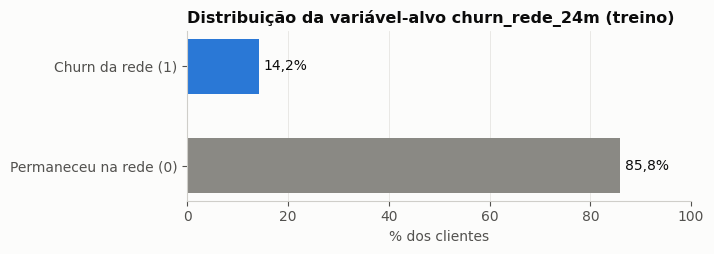

In [3]:
dist_alvo = hist_treino["churn_rede_24m"].value_counts().rename("clientes").to_frame()
dist_alvo["%"] = dist_alvo["clientes"] / len(hist_treino) * 100
display(dist_alvo)

fig, ax = plt.subplots(figsize=(6.5, 2.2))
ax.barh(["Permaneceu na rede (0)", "Churn da rede (1)"], dist_alvo["%"].values, color=[CINZA, CORES[0]], height=0.55)
for i, v in enumerate(dist_alvo["%"].values):
    ax.text(v + 1, i, f"{br(v, 1)}%", va="center", color=TEXTO)
ax.set_xlim(0, 100)
ax.set_xlabel("% dos clientes")
ax.set_title("Distribuição da variável-alvo churn_rede_24m (treino)")
ax.grid(axis="y", visible=False)
salvar(fig, "01_distribuicao_alvo")
plt.show()

* **Tipo de problema:** **classificação binária supervisionada**. O alvo `churn_rede_24m` é 0/1 e conhecido no histórico.
* **Saída do modelo:** uma **probabilidade** (score de 0 a 1). Mais do que dizer "sai ou não sai", o que importa para gerar leads é **ordenar** os clientes do maior para o menor risco.
* **Classes desbalanceadas:** só **14,2 %** dos clientes são churn. Isso define três escolhas: (i) a divisão treino/teste e a validação cruzada são **estratificadas**; (ii) a acurácia **não** é usada como métrica, porque "ninguém sai" já acertaria 85,8 %; (iii) as métricas principais focam na classe positiva: **PR-AUC** (*Average Precision*), **ROC-AUC** e métricas de negócio no *top* 20 % de risco (seção 3.2).

### 1.5 Análise exploratória (EDA)

Todas as análises abaixo usam **apenas variáveis disponíveis no momento da compra** e **apenas o conjunto de treino**.

In [4]:
NUM_COMPRA = ["idade", "renda_mensal", "score_credito", "distancia_concessionaria_km", "km_estimado_mes",
              "valor_veiculo", "entrada_pct", "prazo_financiamento_meses", "prestacao_renda_ratio",
              "sensibilidade_preco_inicial", "organizacao_proxy", "tempo_decisao_dias"]
BIN_COMPRA = ["teve_ford_antes", "usou_troca", "compra_a_vista", "garantia_estendida", "plano_manutencao", "aceitou_marketing"]
CAT_COMPRA = ["regiao", "uso_principal", "canal_compra", "categoria_veiculo", "modelo_veiculo"]
TAXA_GERAL = hist_treino["churn_rede_24m"].mean()

display(hist_treino[NUM_COMPRA].describe().T)

,count,mean,std,min,25%,50%,75%,max
idade,"396,118.0000",41.6346,10.7144,18.0000,34.0000,42.0000,49.0000,85.0000
renda_mensal,"390,148.0000","11,555.3802","6,361.7553","1,800.0000","7,193.0400","10,186.9950","14,346.2925","179,228.1300"
score_credito,"391,814.0000",709.6631,76.2653,335.0000,659.0000,713.0000,763.0000,980.0000
distancia_concessionaria_km,"392,832.0000",21.0317,17.5067,0.5000,8.9000,16.1000,27.8000,364.1000
km_estimado_mes,"400,000.0000","1,647.4481",604.6226,200.0000,"1,246.0000","1,611.0000","2,008.0000","11,724.0000"
valor_veiculo,"400,000.0000","141,936.1608","62,632.7943","55,000.0000","86,346.5325","133,196.9750","192,148.4700","678,148.8500"
entrada_pct,"400,000.0000",0.5218,0.3805,0.0000,0.1990,0.3350,1.0000,1.0000
prazo_financiamento_meses,"400,000.0000",32.3978,27.6829,0.0000,0.0000,39.0000,56.0000,84.0000
prestacao_renda_ratio,"400,000.0000",0.1788,0.2341,0.0000,0.0000,0.1210,0.2660,2.5000
sensibilidade_preco_inicial,"400,000.0000",0.5358,0.2565,0.0000,0.3330,0.5300,0.7510,1.0000


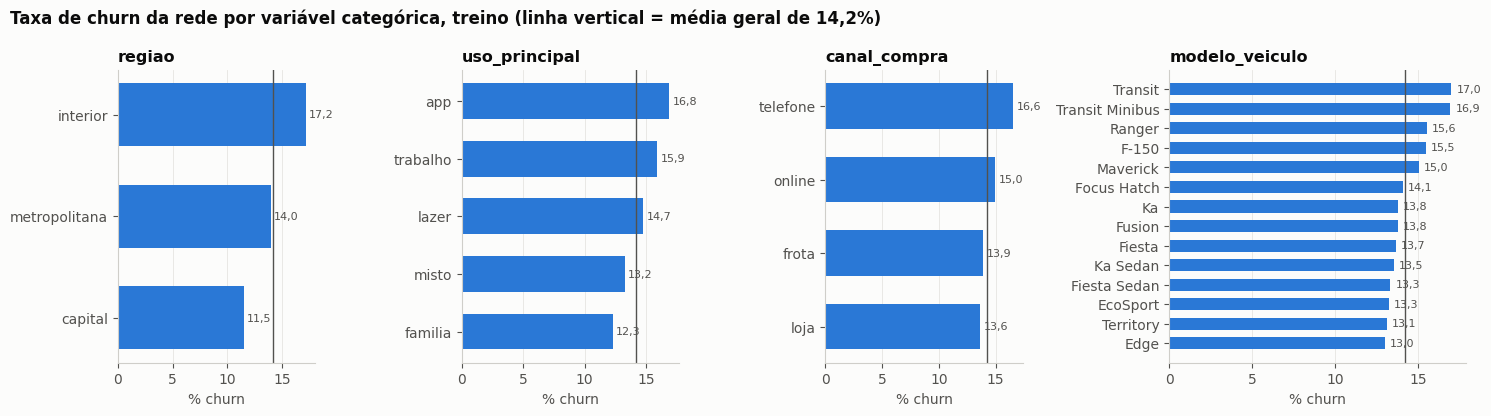

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), gridspec_kw={"width_ratios": [1, 1.1, 1, 1.5]})
for ax, col in zip(axes, ["regiao", "uso_principal", "canal_compra", "modelo_veiculo"]):
    taxa = hist_treino.groupby(col)["churn_rede_24m"].mean().sort_values() * 100
    ax.barh(taxa.index, taxa.values, color=CORES[0], height=0.62)
    ax.axvline(TAXA_GERAL * 100, color=TEXTO_2, lw=1)
    ax.set_title(col)
    ax.set_xlabel("% churn")
    ax.grid(axis="y", visible=False)
    for i, v in enumerate(taxa.values):
        ax.text(v + 0.3, i, br(v, 1), va="center", fontsize=8, color=TEXTO_2)
fig.suptitle(f"Taxa de churn da rede por variável categórica, treino (linha vertical = média geral de {br(TAXA_GERAL * 100, 1)}%)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
salvar(fig, "02_churn_categoricas")
plt.show()

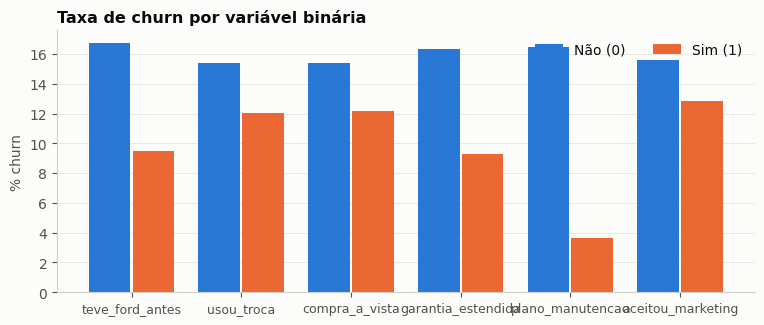

,Não (0),Sim (1)
teve_ford_antes,16.7000,9.5000
usou_troca,15.4000,12.0000
compra_a_vista,15.4000,12.1000
garantia_estendida,16.4000,9.3000
plano_manutencao,16.5000,3.6000
aceitou_marketing,15.6000,12.9000


In [6]:
taxas_bin = pd.DataFrame({c: hist_treino.groupby(c)["churn_rede_24m"].mean() * 100 for c in BIN_COMPRA}).T
taxas_bin.columns = ["Não (0)", "Sim (1)"]
fig, ax = plt.subplots(figsize=(9, 3.4))
pos = np.arange(len(taxas_bin))
ax.bar(pos - 0.2, taxas_bin["Não (0)"], width=0.38, color=CORES[0], label="Não (0)")
ax.bar(pos + 0.2, taxas_bin["Sim (1)"], width=0.38, color=CORES[1], label="Sim (1)")
ax.set_xticks(pos, taxas_bin.index, rotation=0, fontsize=9)
ax.set_ylabel("% churn")
ax.set_title("Taxa de churn por variável binária")
ax.legend(ncols=2, loc="upper right")
ax.grid(axis="x", visible=False)
salvar(fig, "03_churn_binarias")
plt.show()
display(taxas_bin.round(1))

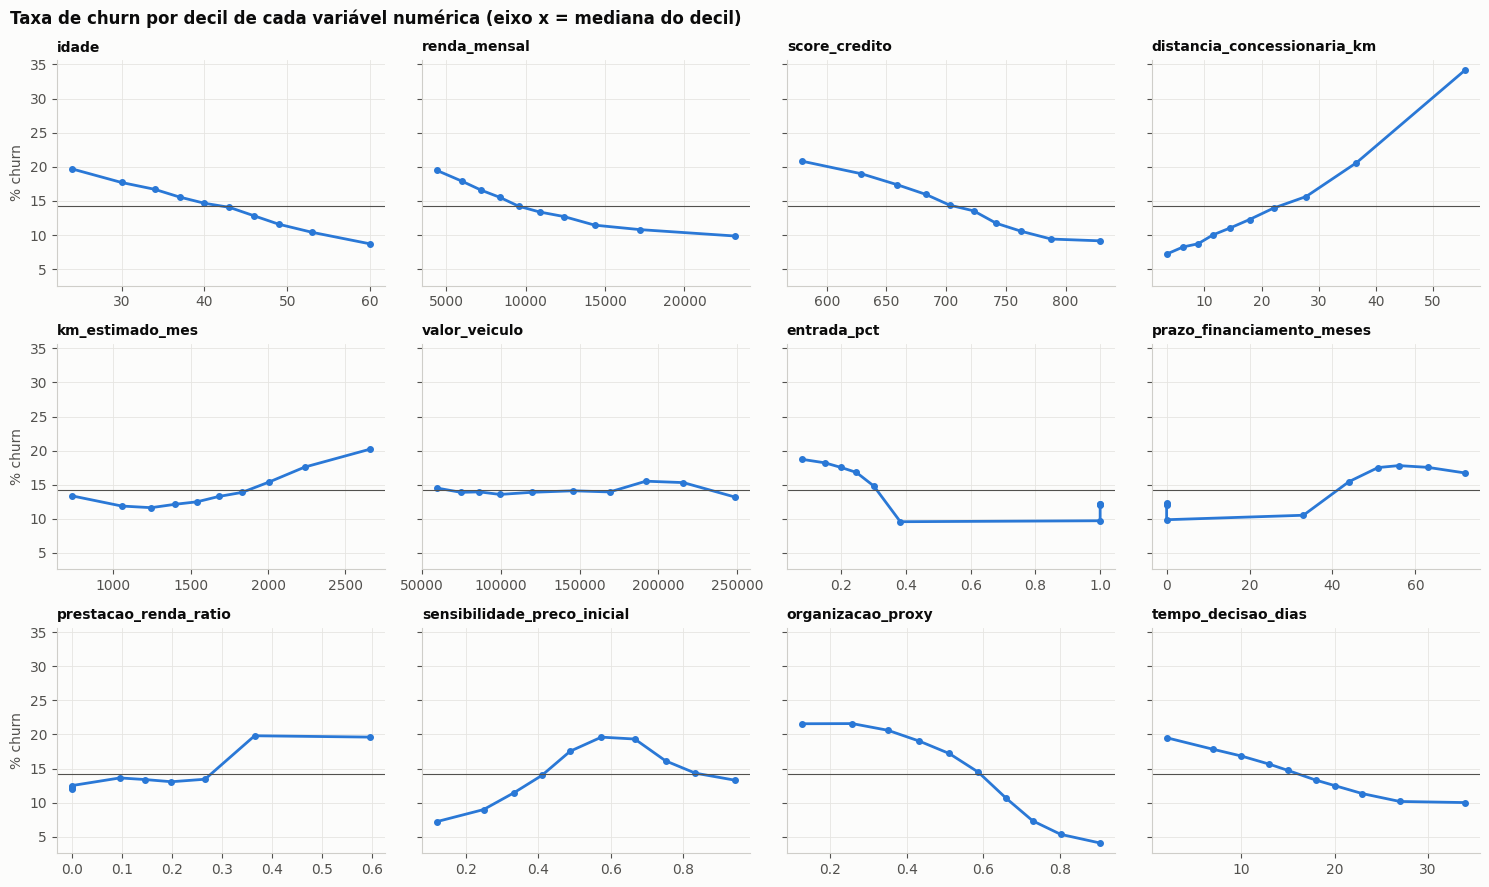

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(15, 9), sharey=True)
for ax, col in zip(axes.ravel(), NUM_COMPRA):
    s = hist_treino[[col, "churn_rede_24m"]].dropna()
    faixas = pd.qcut(s[col].rank(method="first"), 10, labels=False)
    g = s.groupby(faixas).agg(x=(col, "median"), taxa=("churn_rede_24m", "mean"))
    ax.plot(g["x"], g["taxa"] * 100, marker="o", ms=4, color=CORES[0])
    ax.axhline(TAXA_GERAL * 100, color=TEXTO_2, lw=0.8)
    ax.set_title(col, fontsize=10)
axes[0, 0].set_ylabel("% churn")
axes[1, 0].set_ylabel("% churn")
axes[2, 0].set_ylabel("% churn")
fig.suptitle("Taxa de churn por decil de cada variável numérica (eixo x = mediana do decil)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
salvar(fig, "04_churn_numericas_decis")
plt.show()

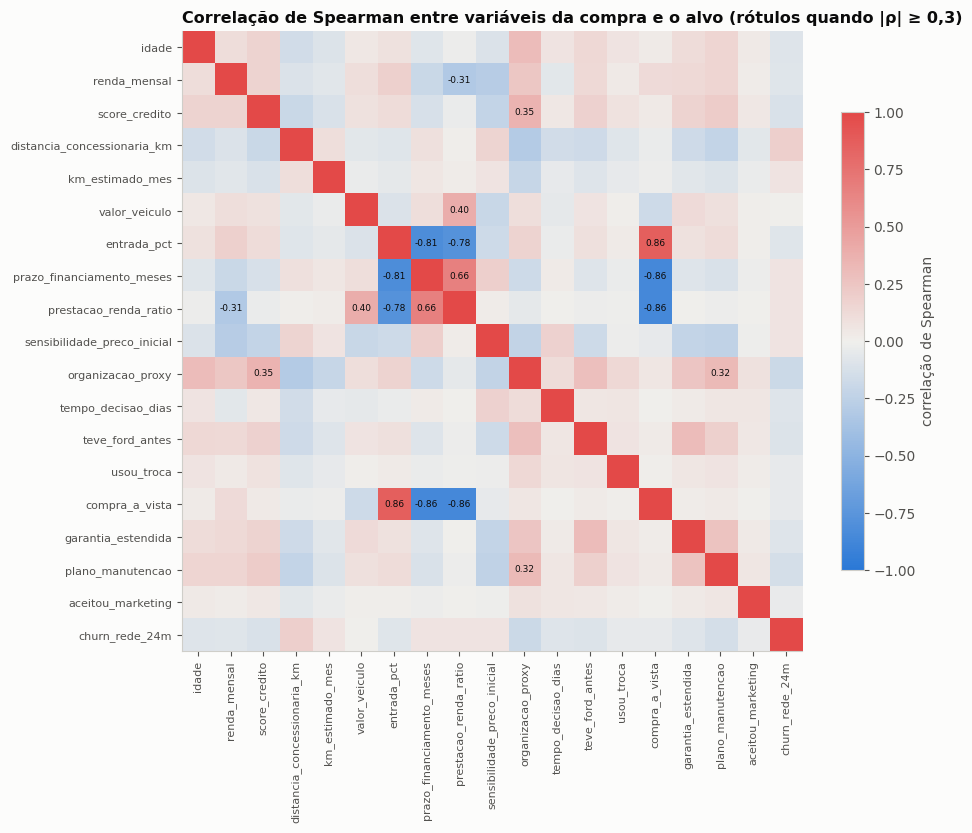

Correlação de cada variável com o alvo (Spearman):


,ρ com churn
distancia_concessionaria_km,0.1894
organizacao_proxy,-0.1830
plano_manutencao,-0.1404
score_credito,-0.1104
teve_ford_antes,-0.0993
garantia_estendida,-0.0936
idade,-0.0930
tempo_decisao_dias,-0.0891
renda_mensal,-0.0859
entrada_pct,-0.0795


In [8]:
corr = hist_treino[NUM_COMPRA + BIN_COMPRA + ["churn_rede_24m"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap=CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        if abs(corr.values[i, j]) >= 0.3 and i != j:
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color=TEXTO)
fig.colorbar(im, ax=ax, shrink=0.7, label="correlação de Spearman")
ax.set_title("Correlação de Spearman entre variáveis da compra e o alvo (rótulos quando |ρ| ≥ 0,3)")
salvar(fig, "05_correlacao")
plt.show()
print("Correlação de cada variável com o alvo (Spearman):")
display(corr["churn_rede_24m"].drop("churn_rede_24m").sort_values(key=abs, ascending=False).to_frame("ρ com churn"))

**Números citados nos achados** (calculados no treino e gravados em `figuras/resumo_resultados.json`):

In [9]:
def decis(col):
    s = hist_treino[[col, "churn_rede_24m"]].dropna()
    faixa = pd.qcut(s[col].rank(method="first"), 10, labels=False)
    return s.groupby(faixa).agg(mediana=(col, "median"), taxa=("churn_rede_24m", "mean"))


def taxas_por(col):
    return {str(k): float(v * 100) for k, v in hist_treino.groupby(col)["churn_rede_24m"].mean().items()}


rho = corr["churn_rede_24m"].drop("churn_rede_24m")
d_dist, d_org, d_score = decis("distancia_concessionaria_km"), decis("organizacao_proxy"), decis("score_credito")
d_sens, d_km = decis("sensibilidade_preco_inicial"), decis("km_estimado_mes")
financiado = (hist_treino["compra_a_vista"] == 0) & (hist_treino["prestacao_renda_ratio"] > 0)
EDA = {
    "populacao": "treino",
    "rho": {k: float(v) for k, v in rho.items()}, "rho_max_abs": float(rho.abs().max()), "rho_max_var": rho.abs().idxmax(),
    "dist_d1_km": float(d_dist["mediana"].iloc[0]), "dist_d1": float(d_dist["taxa"].iloc[0] * 100),
    "dist_d10_km": float(d_dist["mediana"].iloc[-1]), "dist_d10": float(d_dist["taxa"].iloc[-1] * 100),
    "org_d1": float(d_org["taxa"].iloc[0] * 100), "org_d10": float(d_org["taxa"].iloc[-1] * 100),
    "score_d1": float(d_score["taxa"].iloc[0] * 100), "score_d10": float(d_score["taxa"].iloc[-1] * 100),
    "sens_d1": float(d_sens["taxa"].iloc[0] * 100), "sens_max": float(d_sens["taxa"].max() * 100),
    "sens_argmax_decil": int(d_sens["taxa"].values.argmax()) + 1, "km_d10": float(d_km["taxa"].iloc[-1] * 100),
    "prest_ate30": float(hist_treino.loc[financiado & (hist_treino["prestacao_renda_ratio"] <= 0.30), "churn_rede_24m"].mean() * 100),
    "prest_acima30": float(hist_treino.loc[financiado & (hist_treino["prestacao_renda_ratio"] > 0.30), "churn_rede_24m"].mean() * 100),
    "binarias": {c: {"nao": float(taxas_bin.loc[c, "Não (0)"]), "sim": float(taxas_bin.loc[c, "Sim (1)"])} for c in BIN_COMPRA},
    "regiao": taxas_por("regiao"), "canal": taxas_por("canal_compra"), "uso": taxas_por("uso_principal"),
    "categoria": taxas_por("categoria_veiculo"), "modelo": taxas_por("modelo_veiculo"),
    "corr_vista_entrada": float(corr.loc["compra_a_vista", "entrada_pct"]),
    "corr_entrada_prazo": float(corr.loc["entrada_pct", "prazo_financiamento_meses"]),
}
display(pd.Series({k: v for k, v in EDA.items() if isinstance(v, float)}).round(3).to_frame("valor (treino)"))

,valor (treino)
rho_max_abs,0.1890
dist_d1_km,3.4000
dist_d1,7.2040
dist_d10_km,55.6000
dist_d10,34.1770
org_d1,21.5720
org_d10,4.0900
score_d1,20.8360
score_d10,9.1500
sens_d1,7.2220


**Principais achados da EDA:**

1. **Distância até a concessionária** é o fator isolado mais forte (ρ = 0,19). O churn sobe de **7,2 %** entre quem mora a ~3 km para **34,2 %** entre quem mora a ~56 km (1º × 10º decil). Em linha com isso, o **interior** tem churn de 17,2 %, contra 11,5 % nas capitais.
2. **Perfil comportamental na compra:** clientes mais **organizados** (`organizacao_proxy`) saem muito menos (21,6 % → 4,1 % do 1º ao 10º decil, ρ = −0,18). Quem **decide a compra mais rápido** (`tempo_decisao_dias` baixo) sai mais (ρ = −0,09).
3. **Vínculo com a marca está associado a menor churn:** quem contratou **plano de manutenção** tem churn de **3,6 %**, contra 16,5 % de quem não contratou (4,5× menos). Clientes que já tiveram Ford (9,5 % × 16,7 %) e que compraram garantia estendida (9,3 % × 16,4 %) também saem menos.
4. **Perfil financeiro:** score de crédito, idade e renda maiores → menos churn (score: 20,8 % no 1º decil → 9,1 % no 10º). Entre os financiados, parcela acima de 30 % da renda tem churn de 19,7 %, contra 13,3 % até 30 %.
5. **Relações não lineares:** `sensibilidade_preco_inicial` tem forma de "U invertido" (7,2 % no 1º decil, pico de 19,6 % no 6º decil). `km_estimado_mes` só pesa nos maiores valores (10º decil: 20,2 %). `valor_veiculo` praticamente não tem relação com o churn (ρ = 0,003).
6. **Categorias:** vans (17,0 %) e picapes (15,4 %) saem mais que SUVs (13,1 %), sedãs (13,5 %) e hatches (13,8 %). Venda por **telefone** (16,6 %) e **online** (15,0 %) tem mais churn que loja (13,6 %). Uso **app** (16,8 %) tem mais churn que família (12,3 %).
7. **Correlação entre preditores:** as variáveis de financiamento são fortemente ligadas entre si (`compra_a_vista` × `entrada_pct` ρ = 0,86; `entrada_pct` × `prazo` ρ = −0,81). Isso gera multicolinearidade, que atrapalha a leitura dos coeficientes da Regressão Logística (mitigada pela regularização L2) e não afeta modelos de árvore.

**Implicação para a modelagem:** nenhuma variável isolada passa de |ρ| = 0,19. O sinal está **espalhado em muitas variáveis fracas e com relações não lineares**. Isso justifica modelos multivariados e não lineares (ensembles de árvores, rede neural), com a Regressão Logística como *baseline*.

### 1.6 Quais variáveis podem entrar no modelo? (análise de vazamento de dados)

O histórico tem colunas registradas **depois** da compra, e algumas delas medem o próprio desfecho. Por exemplo, `share_revisoes_rede_24m` é a fração de revisões feitas na rede nos mesmos 24 meses que definem o churn. Para medir o "poder de previsão" isolado de cada coluna, calculamos **no treino** a **ROC-AUC univariada** (0,5 = sem informação, 1,0 = separa perfeitamente churn de não churn).

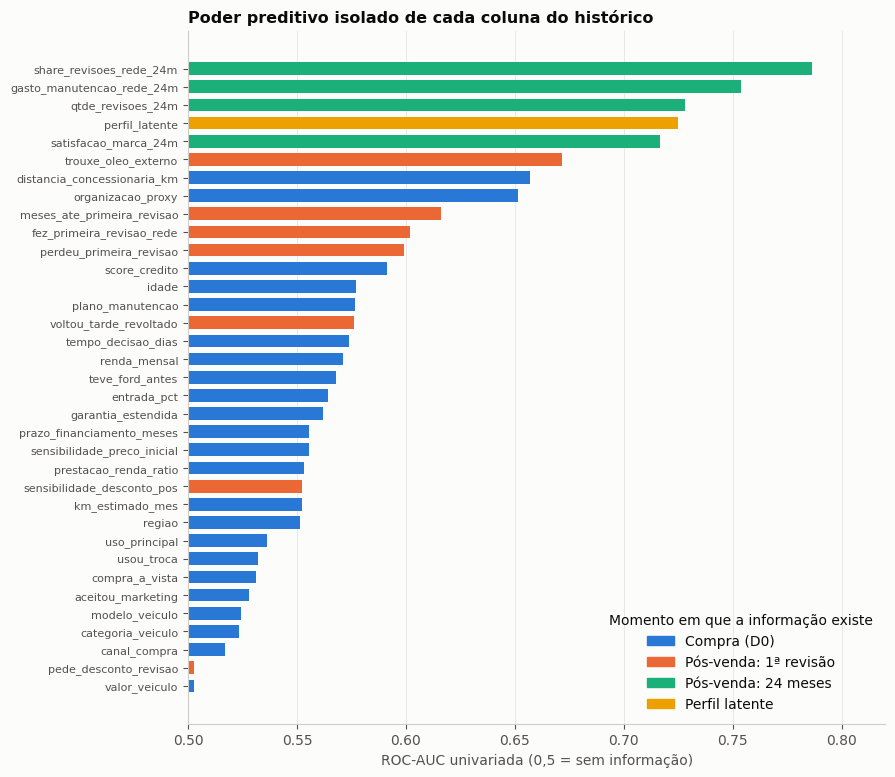

,count,mean,max
grupo,,,
Pós-venda: 24 meses,4,0.7461,0.7863
Perfil latente,1,0.7248,0.7248
Pós-venda: 1ª revisão,7,0.5886,0.6718
Compra (D0),23,0.5589,0.6567


In [10]:
GRUPOS = {
    "Compra (D0)": NUM_COMPRA + BIN_COMPRA + CAT_COMPRA,
    "Pós-venda: 1ª revisão": ["fez_primeira_revisao_rede", "meses_ate_primeira_revisao", "perdeu_primeira_revisao",
                              "voltou_tarde_revoltado", "trouxe_oleo_externo", "pede_desconto_revisao",
                              "sensibilidade_desconto_pos"],
    "Pós-venda: 24 meses": ["qtde_revisoes_24m", "share_revisoes_rede_24m", "gasto_manutencao_rede_24m", "satisfacao_marca_24m"],
    "Perfil latente": ["perfil_latente"],
}


def auc_univariada(serie, alvo):
    if serie.dtype.kind in "fi":
        m = serie.notna()
        auc = roc_auc_score(alvo[m], serie[m])
        return max(auc, 1 - auc)
    return roc_auc_score(alvo, serie.map(alvo.groupby(serie).mean()))  # categórica: taxa média por categoria


linhas = [(col, grupo, auc_univariada(hist_treino[col], hist_treino["churn_rede_24m"])) for grupo, cols in GRUPOS.items() for col in cols]
auc_uni = pd.DataFrame(linhas, columns=["variável", "grupo", "ROC-AUC univariada"]).sort_values("ROC-AUC univariada")

fig, ax = plt.subplots(figsize=(9, 9))
cor_grupo = dict(zip(GRUPOS, CORES))
ax.barh(auc_uni["variável"], auc_uni["ROC-AUC univariada"] - 0.5, left=0.5,
        color=auc_uni["grupo"].map(cor_grupo), height=0.7)
ax.set_xlim(0.5, 0.82)
ax.set_xlabel("ROC-AUC univariada (0,5 = sem informação)")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="y", visible=False)
ax.legend(handles=[Patch(color=c, label=g) for g, c in cor_grupo.items()], loc="lower right",
          title="Momento em que a informação existe")
ax.set_title("Poder preditivo isolado de cada coluna do histórico")
salvar(fig, "06_auc_univariada_vazamento")
plt.show()
display(auc_uni.groupby("grupo")["ROC-AUC univariada"].agg(["count", "mean", "max"]).sort_values("max", ascending=False))

**Decisão:** as colunas mais "preditivas" do histórico são justamente as de **pós-venda em 24 meses**. Isso é esperado, porque elas **descrevem o próprio desfecho**. Um modelo treinado com elas teria ótimas métricas no notebook, mas **seria inútil na prática**: quando a concessionária precisa agir (na venda), essas informações ainda não existem.

```
 Compra (D0) ─────────► 1ª revisão (≈ 6–12 meses) ─────────► fim da janela (24 meses)
 ▲ score gerado aqui     variáveis "pós-venda: 1ª revisão"     variáveis "24 meses" + alvo churn_rede_24m
 (layout do arquivo operacional)
```

Por isso o modelo usa **somente as variáveis do momento da compra**, exatamente as colunas do arquivo `operacional_compra`. A seção 2.5 mede, só com dados de treino, quanto as métricas ficariam artificialmente infladas se essa regra fosse ignorada.

<a id="2"></a>
# 2. Preparação dos dados *(2,0 pontos)*

Ordem adotada para **evitar vazamento**:

1. **Divisão treino/teste** feita logo após a leitura dos dados (1.2), **antes** de qualquer análise com o alvo ou etapa que estima estatísticas (detalhada em 2.4).
2. **Diagnóstico** de ausentes, inconsistências e outliers (2.1), calculado **no treino**.
3. Regras **determinísticas, linha a linha**, que não aprendem nada dos dados: correção de inconsistências (2.2), que também é o **1º passo do pipeline** e é idêntica em produção, e criação de variáveis candidatas (2.3).
4. **Seleção de variáveis** com experimento só no treino (2.5).
5. **Pipeline de transformação** (imputação, winsorização, log, padronização, *one-hot*), **ajustado só no treino** e reaplicado dentro de cada *fold* da validação cruzada (2.6).
6. **Teste das variáveis criadas** com validação cruzada no treino (2.7).

### 2.1 Diagnóstico de qualidade dos dados
#### Valores ausentes

In [11]:
h = hist_treino
cols_com_na = h.columns[h.isna().any()]
tab_na = pd.DataFrame({
    "ausentes": h[cols_com_na].isna().sum(),
    "% ausentes": h[cols_com_na].isna().mean() * 100,
    "churn % com o campo ausente": [h.loc[h[c].isna(), "churn_rede_24m"].mean() * 100 for c in cols_com_na],
    "churn % com o campo presente": [h.loc[h[c].notna(), "churn_rede_24m"].mean() * 100 for c in cols_com_na],
    "p-valor qui² (ausência × churn)": [chi2_contingency(pd.crosstab(h[c].isna(), h["churn_rede_24m"]))[1] for c in cols_com_na],
})
tab_na["usada no modelo?"] = ["sim" if c in NUM_COMPRA + BIN_COMPRA else "não (pós-venda)" for c in cols_com_na]
tab_na = tab_na.sort_values("% ausentes", ascending=False).rename_axis("variável (treino)")
display(tab_na.round(4))

# Checagens estruturais (não usam o alvo nem estimam estatísticas): feitas na base completa
ESTRUTURA = {"populacao": "base completa (estrutura)", "linhas_duplicadas": int(hist.duplicated().sum()),
             "duplicadas_ignorando_id": int(hist.drop(columns="cliente_id").duplicated().sum()),
             "cliente_id_unico": bool(hist["cliente_id"].is_unique)}
print(f"[base completa] linhas duplicadas: {ESTRUTURA['linhas_duplicadas']} | duplicadas ignorando o id: "
      f"{ESTRUTURA['duplicadas_ignorando_id']} | cliente_id único: {ESTRUTURA['cliente_id_unico']}")

,ausentes,% ausentes,churn % com o campo ausente,churn % com o campo presente,p-valor qui² (ausência × churn),usada no modelo?
variável (treino),,,,,,
renda_mensal,9852,2.4630,14.3017,14.1895,0.7638,sim
score_credito,8186,2.0465,14.2683,14.1907,0.8547,sim
distancia_concessionaria_km,7168,1.7920,14.5089,14.1865,0.4483,sim
satisfacao_marca_24m,6047,1.5118,13.8746,14.1971,0.4873,não (pós-venda)
tempo_decisao_dias,4833,1.2082,14.0699,14.1937,0.8224,sim
aceitou_marketing,4030,1.0075,14.4169,14.1900,0.6980,sim
share_revisoes_rede_24m,3994,0.9985,14.2213,14.1920,0.9760,não (pós-venda)
idade,3882,0.9705,14.7604,14.1867,0.3191,sim
teve_ford_antes,3178,0.7945,15.5129,14.1817,0.0343,sim


[base completa] linhas duplicadas: 0 | duplicadas ignorando o id: 0 | cliente_id único: True


* No treino, 12 colunas têm ausentes (9 delas usadas no modelo), todas **abaixo de 2,5 %**. Na base completa não há linhas duplicadas e `cliente_id` é único.
* A taxa de churn dos registros com o campo ausente fica próxima à dos registros com o campo presente (maior diferença: 1,3 p.p., em `teve_ford_antes`). No teste qui², só `teve_ford_antes` tem p < 0,05 (nominal, sem correção para 12 testes). Esses testes **não demonstram** que a ausência é aleatória (*MCAR*). Eles só mostram que ela não está fortemente associada ao churn.
* **Tratamento:** imputação pela **mediana** (numéricas, robusta a outliers) e pela **moda** (binárias e categóricas), **aprendidas só no treino** e dentro do pipeline (2.6). A escolha se justifica pela **baixa proporção de ausentes** e pela simplicidade. Não criamos indicadores de ausência nem descartamos linhas, porque em produção o modelo também vai receber registros incompletos e precisa pontuá-los.

#### Inconsistências lógicas

In [12]:
h = hist_treino
razao_modelo = h["valor_veiculo"] / h.groupby("modelo_veiculo")["valor_veiculo"].transform("median")
checagens = pd.DataFrame([
    ("Financiado (compra_a_vista=0) com prazo = 0 e prestação = 0",
     ((h.compra_a_vista == 0) & (h.prazo_financiamento_meses == 0)).sum(), "prazo e prestação → ausentes → imputados (2.2)"),
    ("À vista com entrada < 100 % ou prazo > 0",
     ((h.compra_a_vista == 1) & ((h.entrada_pct < 1) | (h.prazo_financiamento_meses > 0))).sum(), "nenhum caso"),
    ("Prestação maior que a renda (prestacao_renda_ratio > 1)", (h.prestacao_renda_ratio > 1).sum(), "winsorização (2.6)"),
    ("prestacao_renda_ratio travado no teto de 2,5", (h.prestacao_renda_ratio >= 2.5).sum(), "winsorização (2.6)"),
    ("valor_veiculo exatamente no piso de R$ 55.000", (h.valor_veiculo == 55000).sum(), "mantido (valor plausível; piso da geração)"),
    ("valor_veiculo > 2× a mediana do próprio modelo", (razao_modelo > 2).sum(), "winsorização (2.6)"),
    ("modelo_veiculo associado a mais de uma categoria",
     (h.groupby("modelo_veiculo")["categoria_veiculo"].nunique() > 1).sum(), "nenhum caso → categoria é redundante (2.5)"),
    ("idade fora de 18–100, score fora de 0–1000 ou valores negativos",
     ((h.idade < 18) | (h.idade > 100) | (h.score_credito < 0) | (h.score_credito > 1000)).sum()
     + int((h.select_dtypes("number") < 0).sum().sum()), "nenhum caso"),
    ("[pós-venda] qtde_revisoes_24m = 0 mas share_revisoes_rede_24m > 0",
     ((h.qtde_revisoes_24m == 0) & (h.share_revisoes_rede_24m > 0)).sum(), "coluna excluída do modelo (vazamento)"),
], columns=["checagem", "registros no treino", "tratamento"])
display(checagens)

# Coerência da prestação com os demais campos (financiados com prazo > 0, no treino)
fin = h[(h.compra_a_vista == 0) & (h.prazo_financiamento_meses > 0) & h.renda_mensal.notna()]
parcela_simples = fin.valor_veiculo * (1 - fin.entrada_pct) / fin.prazo_financiamento_meses / fin.renda_mensal
PRESTACAO = {"populacao": "treino (financiados com prazo > 0)",
             "fator_mediano": float((fin.prestacao_renda_ratio / parcela_simples).median()),
             "correlacao": float(np.corrcoef(np.clip(parcela_simples, 0, 2.5), fin.prestacao_renda_ratio)[0, 1])}
print(f"prestacao_renda_ratio ≈ valor × (1 − entrada) / prazo / renda × {PRESTACAO['fator_mediano']:.3f} (mediana); "
      f"correlação = {PRESTACAO['correlacao']:.3f}")

,checagem,registros no treino,tratamento
0,Financiado (compra_a_vista=0) com prazo = 0 e ...,267,prazo e prestação → ausentes → imputados (2.2)
1,À vista com entrada < 100 % ou prazo > 0,0,nenhum caso
2,Prestação maior que a renda (prestacao_renda_r...,4250,winsorização (2.6)
3,"prestacao_renda_ratio travado no teto de 2,5",368,winsorização (2.6)
4,valor_veiculo exatamente no piso de R$ 55.000,13267,mantido (valor plausível; piso da geração)
5,valor_veiculo > 2× a mediana do próprio modelo,403,winsorização (2.6)
6,modelo_veiculo associado a mais de uma categoria,0,nenhum caso → categoria é redundante (2.5)
7,"idade fora de 18–100, score fora de 0–1000 ou ...",0,nenhum caso
8,[pós-venda] qtde_revisoes_24m = 0 mas share_re...,30075,coluna excluída do modelo (vazamento)


prestacao_renda_ratio ≈ valor × (1 − entrada) / prazo / renda × 1.018 (mediana); correlação = 0.997


A prestação é coerente com os demais campos: `prestacao_renda_ratio` ≈ `valor × (1 − entrada) / prazo / renda × 1,018` (juros embutidos, correlação 0,997). Isso indica que os **267 financiamentos com prazo 0** do treino são erros de registro, e não compras à vista.

#### Outliers

,"outliers (IQR 1,5)",% outliers,mín,"p0,5",mediana,"p99,5",máx
variável (treino),,,,,,,
renda_mensal,14000,3.5900,"1,800.0000","2,764.9700","10,186.9900","37,209.1600","179,228.1300"
distancia_concessionaria_km,18977,4.8300,0.5000,1.1000,16.1000,95.4000,364.1000
km_estimado_mes,4719,1.1800,200.0000,212.0000,"1,611.0000","3,458.0000","11,724.0000"
valor_veiculo,260,0.0600,"55,000.0000","55,000.0000","133,196.9800","296,310.0800","678,148.8500"
prestacao_renda_ratio,14687,3.6700,0.0000,0.0000,0.1200,1.2700,2.5000
idade,1118,0.2800,18.0000,18.0000,42.0000,70.0000,85.0000
score_credito,2471,0.6300,335.0000,501.0000,713.0000,889.0000,980.0000
tempo_decisao_dias,3473,0.8800,1.0000,1.0000,16.0000,45.0000,70.0000


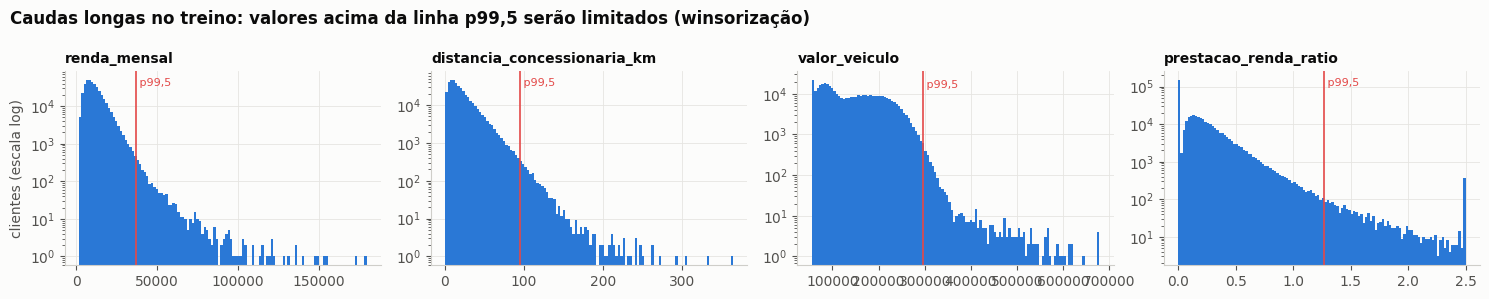

In [13]:
CONTINUAS_OUT = ["renda_mensal", "distancia_concessionaria_km", "km_estimado_mes", "valor_veiculo",
                 "prestacao_renda_ratio", "idade", "score_credito", "tempo_decisao_dias"]
linhas = []
for c in CONTINUAS_OUT:
    s = hist_treino[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    linhas.append((c, ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum(), ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100,
                   s.min(), s.quantile(0.005), s.median(), s.quantile(0.995), s.max()))
tab_out = pd.DataFrame(linhas, columns=["variável (treino)", "outliers (IQR 1,5)", "% outliers", "mín", "p0,5", "mediana", "p99,5", "máx"]).set_index("variável (treino)")
display(tab_out.round(2))

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, c in zip(axes, ["renda_mensal", "distancia_concessionaria_km", "valor_veiculo", "prestacao_renda_ratio"]):
    s = hist_treino[c].dropna()
    ax.hist(s, bins=120, color=CORES[0])
    ax.axvline(s.quantile(0.995), color=CORES[7], lw=1.2)
    ax.set_title(c, fontsize=10)
    ax.set_yscale("log")
    ax.text(s.quantile(0.995), ax.get_ylim()[1] * 0.4, " p99,5", color=CORES[7], fontsize=8)
axes[0].set_ylabel("clientes (escala log)")
fig.suptitle("Caudas longas no treino: valores acima da linha p99,5 serão limitados (winsorização)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
salvar(fig, "07_outliers")
plt.show()

* Há **caudas longas à direita** no treino: renda até R$ 179 mil/mês, distância até 364 km, prestação de até 2,5× a renda e 403 veículos acima de 2× a mediana do próprio modelo.
* **Tratamento: winsorização** (limitar cada variável contínua entre os percentis 0,5 % e 99,5 % **aprendidos no treino**) em vez de excluir linhas. Assim mantemos os clientes (em produção eles também vão aparecer) e reduzimos a influência dos extremos em modelos sensíveis à escala (Regressão Logística e Rede Neural). Em seguida, as variáveis monetárias e de distância recebem **log(1+x)** para reduzir a assimetria. Modelos de árvore não são afetados por essas transformações monotônicas.

### 2.2 Correção de inconsistências (regra determinística)

A função `corrigir_inconsistencias` aplica a regra **linha a linha**, sem aprender nada do conjunto: financiamento com `prazo = 0` → `prazo` e `prestacao_renda_ratio` viram **ausentes** e depois são imputados pelo pipeline (2.6). Os demais problemas (valores extremos, prestação acima da renda) são tratados pela winsorização do pipeline.

Todo o código de pré-processamento próprio é gravado **de uma vez** no módulo **`ford_churn_pipeline.py`** (célula abaixo): esta regra e o `Winsorizer`, usado na seção 2.6. O notebook importa desse módulo, e a API de produção importaria o mesmo arquivo. Assim, o modelo salvo não depende do notebook (validação em processo separado na seção 5.3). A correção também é o **1º passo do pipeline**, então o modelo recebe os dados crus do layout operacional.

In [14]:
%%writefile ford_churn_pipeline.py
"""Pré-processamento do modelo de churn da rede Ford (Desafio 02). Usado no treino (notebook) e na produção (API)."""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


def corrigir_inconsistencias(df):
    """Regra determinística (linha a linha): financiamento com prazo 0 → prazo e prestação ausentes."""
    d = df.copy()
    financiado_sem_prazo = (d["compra_a_vista"] == 0) & (d["prazo_financiamento_meses"] == 0)
    d.loc[financiado_sem_prazo, ["prazo_financiamento_meses", "prestacao_renda_ratio"]] = np.nan
    return d


class Winsorizer(BaseEstimator, TransformerMixin):
    """Limita cada coluna entre os quantis q_inf e q_sup aprendidos no treino (tratamento de outliers)."""

    def __init__(self, q_inf=0.005, q_sup=0.995):
        self.q_inf = q_inf
        self.q_sup = q_sup

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.limite_inf_ = X.quantile(self.q_inf).to_numpy()
        self.limite_sup_ = X.quantile(self.q_sup).to_numpy()
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.limite_inf_, self.limite_sup_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

Overwriting ford_churn_pipeline.py


In [15]:
import ford_churn_pipeline
importlib.reload(ford_churn_pipeline)
from ford_churn_pipeline import corrigir_inconsistencias, Winsorizer

dados = corrigir_inconsistencias(hist)
print("[base completa, verificação da regra] financiamentos com prazo 0 antes:",
      int(((hist.compra_a_vista == 0) & (hist.prazo_financiamento_meses == 0)).sum()),
      "| depois:", int(((dados.compra_a_vista == 0) & (dados.prazo_financiamento_meses == 0)).sum()))

[base completa, verificação da regra] financiamentos com prazo 0 antes: 330 | depois: 0


### 2.3 Criação de variáveis (conhecimento do negócio)

Criamos três variáveis candidatas. A seção 2.5 testa se elas **realmente melhoram** o modelo antes de mantê-las.

| Nova variável | Fórmula | Racional |
|---|---|---|
| `valor_financiado` | `valor_veiculo × (1 − entrada_pct)` | peso da dívida assumida; cliente endividado tende a cortar custo de manutenção |
| `valor_veiculo_sobre_renda` | `valor_veiculo / renda_mensal` | esforço de compra (quantos meses de renda o carro custou) |
| `revisoes_esperadas_24m` | `max(2, km_estimado_mes × 24 / 10.000)` | plano de revisões Ford (a cada 10 mil km **ou** 12 meses, o que vier primeiro): quem roda mais tem mais revisões e mais oportunidades de sair da rede |

In [16]:
def criar_variaveis(df):
    d = df.copy()
    d["valor_financiado"] = d["valor_veiculo"] * (1 - d["entrada_pct"])
    d["valor_veiculo_sobre_renda"] = d["valor_veiculo"] / d["renda_mensal"]
    d["revisoes_esperadas_24m"] = np.maximum(2, d["km_estimado_mes"] * 24 / 10_000)
    return d


NOVAS = ["valor_financiado", "valor_veiculo_sobre_renda", "revisoes_esperadas_24m"]
dados = criar_variaveis(dados)
dados_tr = dados.loc[idx_treino]
display(dados_tr[NOVAS].describe().T)
display(pd.DataFrame({c: dados_tr.groupby(pd.qcut(dados_tr[c].rank(method="first"), 5, labels=[f"Q{i}" for i in range(1, 6)]))
                         ["churn_rede_24m"].mean() * 100 for c in NOVAS}).T.round(1).rename_axis("churn % por quintil (treino)"))

,count,mean,std,min,25%,50%,75%,max
valor_financiado,"400,000.0000","71,352.3059","67,743.3888",0.0000,0.0000,"65,128.9983","125,588.6125","597,580.9496"
valor_veiculo_sobre_renda,"390,148.0000",15.5690,10.9552,0.5350,8.0494,12.6736,19.8424,172.8072
revisoes_esperadas_24m,"400,000.0000",3.9940,1.3822,2.0000,2.9904,3.8664,4.8192,28.1376


,Q1,Q2,Q3,Q4,Q5
churn % por quintil (treino),,,,,
valor_financiado,12.1000,12.3000,13.7000,14.6000,18.3000
valor_veiculo_sobre_renda,12.5000,12.2000,12.7000,14.1000,19.5000
revisoes_esperadas_24m,12.6000,11.9000,12.9000,14.6000,18.9000


### 2.4 Divisão em treino e teste

* **80 % treino / 20 % teste**, **estratificada** pelo alvo (mesma proporção de churn nos dois conjuntos) e com semente fixa. A separação foi feita logo após a leitura dos dados (seção 1.2).
* **Nesta execução, a exploração e as decisões de desenvolvimento usam apenas o treino. O conjunto de teste é usado para a avaliação final (seção 4), sem participar do ajuste dos estimadores, da busca de hiperparâmetros ou da definição dos limiares.**

In [17]:
treino, teste = dados.loc[idx_treino], dados.loc[idx_teste]
y_tr, y_te = treino["churn_rede_24m"], teste["churn_rede_24m"]
display(pd.DataFrame({"linhas": [len(treino), len(teste)], "% churn": [y_tr.mean() * 100, y_te.mean() * 100]},
                     index=["treino", "teste"]).round(3))

,linhas,% churn
treino,400000,14.1920
teste,100000,14.1920


### 2.5 Seleção de variáveis

**Excluídas:**

| Variável(is) | Motivo |
|---|---|
| `cliente_id` | identificador, sem significado preditivo |
| `perfil_latente` | variável oculta que gerou os dados sintéticos; **não existe no mundo real** |
| 7 variáveis da 1ª revisão | só existem **depois** da compra; o score seria gerado tarde demais |
| 4 variáveis de 24 meses | medidas **na mesma janela do alvo** (vazamento) |
| `categoria_veiculo` | **redundante**: é função exata de `modelo_veiculo` (cada modelo pertence a uma única categoria, ver tabela abaixo) |

**Mantidas:** as outras **22 variáveis da compra**. As 3 variáveis criadas em 2.3 passam por um teste próprio na seção 2.7.

In [18]:
display(pd.crosstab(hist_treino["modelo_veiculo"], hist_treino["categoria_veiculo"]).astype(bool).replace({True: "✔", False: ""}))

categoria_veiculo,hatch,picape,sedan,suv,van
modelo_veiculo,,,,,
EcoSport,,,,✔,
Edge,,,,✔,
F-150,,✔,,,
Fiesta,✔,,,,
Fiesta Sedan,,,✔,,
Focus Hatch,✔,,,,
Fusion,,,✔,,
Ka,✔,,,,
Ka Sedan,,,✔,,


**Experimento que confirma a decisão (só com dados de treino):** treinamos o mesmo XGBoost com quatro conjuntos de variáveis, usando uma divisão interna do **treino** (80/20). O teste continua intocado.

22 variáveis da compra selecionadas: ['renda_mensal', 'distancia_concessionaria_km', 'valor_veiculo', 'km_estimado_mes', 'idade', 'score_credito', 'entrada_pct', 'prazo_financiamento_meses', 'prestacao_renda_ratio', 'sensibilidade_preco_inicial', 'organizacao_proxy', 'tempo_decisao_dias', 'teve_ford_antes', 'usou_troca', 'compra_a_vista', 'garantia_estendida', 'plano_manutencao', 'aceitou_marketing', 'regiao', 'uso_principal', 'canal_compra', 'modelo_veiculo']


,nº vars,PR-AUC,ROC-AUC
conjunto de variáveis,,,
A) Compra (D0) — escolhido,22,0.3058,0.7415
B) Compra + 1ª revisão,29,0.4136,0.7979
C) Compra + 1ª revisão + 24 meses,33,0.4578,0.8415
D) Compra + perfil latente,23,0.3184,0.7543


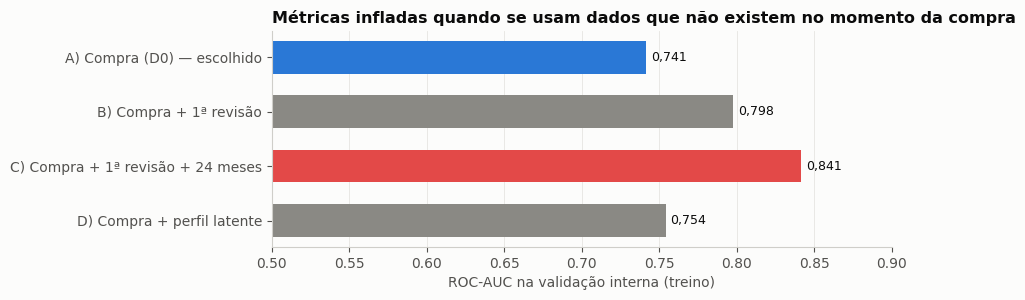

In [19]:
ASSIMETRICAS = ["renda_mensal", "distancia_concessionaria_km", "valor_veiculo", "km_estimado_mes"]
CONTINUAS = ["idade", "score_credito", "entrada_pct", "prazo_financiamento_meses", "prestacao_renda_ratio",
             "sensibilidade_preco_inicial", "organizacao_proxy", "tempo_decisao_dias"]
BINARIAS = BIN_COMPRA
CATEGORICAS = ["regiao", "uso_principal", "canal_compra", "modelo_veiculo"]
FEATURES = ASSIMETRICAS + CONTINUAS + BINARIAS + CATEGORICAS
print(f"{len(FEATURES)} variáveis da compra selecionadas:", FEATURES)

POS_1REV = GRUPOS["Pós-venda: 1ª revisão"]
POS_24M = GRUPOS["Pós-venda: 24 meses"]
conjuntos = {
    "A) Compra (D0) — escolhido": FEATURES,
    "B) Compra + 1ª revisão": FEATURES + POS_1REV,
    "C) Compra + 1ª revisão + 24 meses": FEATURES + POS_1REV + POS_24M,
    "D) Compra + perfil latente": FEATURES + ["perfil_latente"],
}
tr_in, val_in = train_test_split(treino.index, test_size=0.20, stratify=y_tr, random_state=SEED)
linhas = []
for nome, cols in conjuntos.items():
    Xa = treino[cols].copy()
    for c in Xa.columns[Xa.dtypes == "object"].tolist() + [c for c in Xa.columns if str(Xa[c].dtype) in ("str", "string")]:
        Xa[c] = Xa[c].astype("category")
    m = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8,
                      tree_method="hist", enable_categorical=True, n_jobs=-1, random_state=SEED)
    m.fit(Xa.loc[tr_in], y_tr.loc[tr_in])
    p = m.predict_proba(Xa.loc[val_in])[:, 1]
    linhas.append((nome, len(cols), average_precision_score(y_tr.loc[val_in], p), roc_auc_score(y_tr.loc[val_in], p)))
ablacao = pd.DataFrame(linhas, columns=["conjunto de variáveis", "nº vars", "PR-AUC", "ROC-AUC"]).set_index("conjunto de variáveis")
display(ablacao.round(4))

fig, ax = plt.subplots(figsize=(8, 2.8))
cores_abl = [CORES[0], CINZA, CORES[7], CINZA]
ax.barh(ablacao.index[::-1], ablacao["ROC-AUC"][::-1], color=cores_abl[::-1], height=0.6)
for i, v in enumerate(ablacao["ROC-AUC"][::-1]):
    ax.text(v + 0.003, i, br(v, 3), va="center", fontsize=9)
ax.set_xlim(0.5, 0.9)
ax.set_xlabel("ROC-AUC na validação interna (treino)")
ax.grid(axis="y", visible=False)
ax.set_title("Métricas infladas quando se usam dados que não existem no momento da compra")
salvar(fig, "08_ablacao_vazamento")
plt.show()

**Leitura do experimento:**

* Com as variáveis da **1ª revisão**, a PR-AUC sobe de 0,306 para **0,414**. Com as de **24 meses**, chega a **0,458** (+50 %). Esse ganho é **ilusório para o objetivo**: são informações que só existem depois da venda, e as de 24 meses medem o próprio desfecho (`share_revisoes_rede_24m` é praticamente o VIN Share do cliente). Um modelo assim não pode ser usado no momento em que a concessionária precisa agir.
* O conjunto **D** acrescenta o **perfil latente verdadeiro** do cliente, informação impossível de obter na prática. Neste experimento, acrescentar o perfil latente elevou a PR-AUC de 0,306 para **0,318**. O resultado não estabelece um teto de desempenho.
* O conjunto **B** é uma evolução legítima para o futuro: um segundo modelo, acionado **depois da 1ª revisão**, pode refinar os leads (seção 5.4).

### 2.6 Transformação, normalização e padronização (pipeline)

| Tipo de variável | Etapas (na ordem) | Por quê |
|---|---|---|
| Contínuas assimétricas (renda, distância, valores, km) | winsorização p0,5–p99,5 → imputação pela mediana → `log(1+x)` → padronização (z-score) | reduz o efeito dos extremos e a assimetria; deixa tudo na mesma escala |
| Demais contínuas | winsorização p0,5–p99,5 → imputação pela mediana → padronização (z-score) | mesma escala para Regressão Logística e Rede Neural |
| Binárias (0/1) | imputação pela moda | já estão em 0/1 |
| Categóricas | imputação pela moda → *one-hot encoding* (`handle_unknown="ignore"`) | algoritmos precisam de entrada numérica; categorias novas em produção não quebram o modelo |

Tudo fica dentro de um **`Pipeline` do scikit-learn**: `corrigir_inconsistencias` → `ColumnTransformer` (tabela acima) → modelo. Assim, os parâmetros (quantis, medianas, médias, desvios, categorias) são **aprendidos só no treino de cada fold** e o mesmo objeto é salvo para produção. O `Winsorizer` (limites aprendidos no treino) está no módulo `ford_churn_pipeline.py`, gravado na seção 2.2.

In [20]:
def criar_preprocessador(com_novas=False):
    assimetricas = ASSIMETRICAS + (["valor_financiado", "valor_veiculo_sobre_renda"] if com_novas else [])
    continuas = CONTINUAS + (["revisoes_esperadas_24m"] if com_novas else [])
    return ColumnTransformer([
        ("assim", Pipeline([("winsor", Winsorizer()), ("imput", SimpleImputer(strategy="median")),
                            ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                            ("padron", StandardScaler())]), assimetricas),
        ("cont", Pipeline([("winsor", Winsorizer()), ("imput", SimpleImputer(strategy="median")),
                           ("padron", StandardScaler())]), continuas),
        ("bin", SimpleImputer(strategy="most_frequent"), BINARIAS),
        ("cat", Pipeline([("imput", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CATEGORICAS),
    ], verbose_feature_names_out=False)


def criar_pipeline(modelo, com_novas=False):
    return Pipeline([("corrige", FunctionTransformer(corrigir_inconsistencias)),
                     ("prep", criar_preprocessador(com_novas)), ("modelo", modelo)])


X_tr, X_te = treino[FEATURES], teste[FEATURES]

# Demonstração: pré-processador ajustado apenas no treino
prep_demo = criar_preprocessador().fit(X_tr)
Xt_demo = pd.DataFrame(prep_demo.transform(X_tr), columns=prep_demo.get_feature_names_out())
print(f"Matriz após transformação: {Xt_demo.shape[0]:,} linhas × {Xt_demo.shape[1]} colunas "
      f"({len(ASSIMETRICAS) + len(CONTINUAS)} numéricas + {len(BINARIAS)} binárias + one-hot das categóricas)")
print("Ausentes após o pipeline:", int(Xt_demo.isna().sum().sum()))
w = prep_demo.named_transformers_["assim"].named_steps["winsor"]
w2 = prep_demo.named_transformers_["cont"].named_steps["winsor"]
display(pd.DataFrame({"limite inferior (p0,5)": np.r_[w.limite_inf_, w2.limite_inf_],
                      "limite superior (p99,5)": np.r_[w.limite_sup_, w2.limite_sup_]},
                     index=ASSIMETRICAS + CONTINUAS).round(3).rename_axis("limites de winsorização aprendidos no treino"))
display(Xt_demo[ASSIMETRICAS + CONTINUAS].describe().T[["mean", "std", "min", "max"]].round(3))

Matriz após transformação: 400,000 linhas × 44 colunas (12 numéricas + 6 binárias + one-hot das categóricas)
Ausentes após o pipeline: 0


,"limite inferior (p0,5)","limite superior (p99,5)"
limites de winsorização aprendidos no treino,,
renda_mensal,"2,764.9750","37,209.1550"
distancia_concessionaria_km,1.1000,95.4000
valor_veiculo,"55,000.0000","296,310.0760"
km_estimado_mes,212.0000,"3,458.0000"
idade,18.0000,70.0000
score_credito,501.0000,889.0000
entrada_pct,0.0000,1.0000
prazo_financiamento_meses,0.0000,84.0000
prestacao_renda_ratio,0.0000,1.2670


,mean,std,min,max
renda_mensal,-0.0000,1.0000,-2.6180,2.6160
distancia_concessionaria_km,-0.0000,1.0000,-2.7080,2.3020
valor_veiculo,-0.0000,1.0000,-1.8340,1.8210
km_estimado_mes,-0.0000,1.0000,-4.7520,1.9730
idade,-0.0000,1.0000,-2.2240,2.6720
score_credito,0.0000,1.0000,-2.7900,2.3950
entrada_pct,0.0000,1.0000,-1.3710,1.2570
prazo_financiamento_meses,-0.0000,1.0000,-1.1720,1.8640
prestacao_renda_ratio,-0.0000,1.0000,-0.8130,5.0270
sensibilidade_preco_inicial,0.0000,1.0000,-2.0890,1.8090


### 2.7 As variáveis criadas melhoram o modelo?

Comparamos, com **validação cruzada estratificada 5-fold no treino** (mesmos folds para os dois lados), o modelo com as 22 variáveis originais e o modelo com as 22 + 3 criadas. Usamos um modelo linear (Regressão Logística) e um de árvores (XGBoost).

In [21]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_tr_com_novas = treino[FEATURES + NOVAS]
linhas = []
for nome, modelo in [("Regressão Logística", LogisticRegression(C=1.0, max_iter=2000)),
                     ("XGBoost", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                                               colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=SEED))]:
    paralelo = 1 if nome == "XGBoost" else 5
    sem = cross_validate(criar_pipeline(modelo), X_tr, y_tr, cv=cv5, scoring="average_precision", n_jobs=paralelo)["test_score"]
    com = cross_validate(criar_pipeline(modelo, com_novas=True), X_tr_com_novas, y_tr, cv=cv5,
                         scoring="average_precision", n_jobs=paralelo)["test_score"]
    linhas.append((nome, sem.mean(), com.mean(), (com - sem).mean(), (com - sem).std(), (com > sem).sum()))
tab_fe = pd.DataFrame(linhas, columns=["modelo", "PR-AUC 22 originais", "PR-AUC 22 + 3 criadas", "ganho médio",
                                       "dp do ganho entre folds", "folds em que as criadas venceram (de 5)"]).set_index("modelo")
display(tab_fe.round(4))

,PR-AUC 22 originais,PR-AUC 22 + 3 criadas,ganho médio,dp do ganho entre folds,folds em que as criadas venceram (de 5)
modelo,,,,,
Regressão Logística,0.2724,0.2722,-0.0002,0.0004,3
XGBoost,0.3046,0.3045,-0.0000,0.0006,3


**Resultado: as variáveis criadas não trouxeram ganho.** A diferença média foi −0,0002 (Regressão Logística) e −0,0000 (XGBoost). As variáveis criadas venceram em 3 de 5 folds (equivale a cara ou coroa), e a diferença é mais de 10× menor que o desvio-padrão da PR-AUC entre folds (≈ 0,003). A informação delas já está nas variáveis originais: `prestacao_renda_ratio` já mede o peso da dívida em relação à renda, e as árvores aproximam razões e limiares sozinhas.

**Decisão (parcimônia):** o modelo final usa só as **22 variáveis originais da compra**. O desempenho fica próximo, sem diferença detectada, com menos cálculos em produção e menos pontos de falha. O teste fica registrado como evidência de que a seleção de variáveis foi **testada, e não presumida**.

<a id="3"></a>
# 3. Desenvolvimento dos modelos *(3,0 pontos)*

### 3.1 Algoritmos escolhidos e justificativa

| Algoritmo | Família | Por que foi escolhido | Configuração inicial |
|---|---|---|---|
| *Dummy* (prevalência) | referência | piso de comparação: um modelo que "não aprende" tem PR-AUC = 0,142 e ROC-AUC = 0,5 | `strategy="prior"` |
| **Regressão Logística** | linear | *baseline* interpretável (coeficientes = efeito de cada variável), rápida, produz probabilidades bem calibradas | `C=1`, regularização L2 |
| **Árvore de Decisão** | árvore | gera **regras explicáveis** para a concessionária e capta relações não lineares | `max_depth=8`, `min_samples_leaf=200` (contém *overfitting*) |
| **Random Forest** | *ensemble* (bagging) | reduz a variância da árvore única com média de várias árvores; robusta a outliers e escala | 200 árvores, `max_depth=14` |
| **XGBoost** | *ensemble* (boosting) | estado da arte em dados tabulares; capta interações e tem regularização | 400 árvores, `learning_rate=0.05`, `max_depth=5` |
| **Rede Neural (MLP)** | rede neural *feedforward* | aproxima relações não lineares complexas; parte do conteúdo de redes neurais | camadas 64→32, ReLU, Adam, *early stopping* |

**Não usados:** **SVM com kernel** e **KNN**. Com 400 mil linhas de treino, o SVM tem custo de treino entre O(n²) e O(n³), e o KNN precisa comparar cada cliente novo com todo o treino na predição. Os dois seriam inviáveis para pontuar clientes em tempo real, sem vantagem esperada sobre os *ensembles*.

### 3.2 Estratégia de validação e métricas

* **Validação cruzada estratificada 5-fold** no conjunto de treino. Cada modelo é treinado 5 vezes, sempre avaliado em dados que não viu. Reportamos **média ± desvio-padrão**, que mede desempenho **e** estabilidade.
* **Métrica principal: PR-AUC (*Average Precision*).** Resume precisão × *recall* da classe churn em todos os limiares. É a métrica mais informativa com classe positiva rara (14 %) e mede exatamente a qualidade da lista de leads. Referência aleatória = 0,142.
* **Métricas complementares:**
  * **ROC-AUC**: capacidade geral de ordenar churn acima de não churn.
  * **Brier score**: qualidade das probabilidades; importa porque o score vira faixa de risco.
  * **Métricas de negócio @20 %**: se a concessionária contatar os **20 % de clientes com maior risco**, qual fração deles de fato sai (*precision*@20 %), que fração de todos os churners é alcançada (*recall*@20 %) e quantas vezes isso supera uma escolha aleatória (*lift*@20 %).
* **Desbalanceamento:** com ~57 mil churners no treino há exemplos suficientes da classe minoritária, então não fazemos *oversampling* (SMOTE), que distorceria as probabilidades. O uso de **pesos de classe** é testado como configuração (3.4).

In [22]:
METRICAS_CV ={"PR-AUC": "average_precision", "ROC-AUC": "roc_auc", "Brier": "neg_brier_score"}

modelos_base = {
    "Dummy (prevalência)": DummyClassifier(strategy="prior"),
    "Regressão Logística": LogisticRegression(C=1.0, max_iter=2000),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=8, min_samples_leaf=200, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=14, min_samples_leaf=50,
                                            n_jobs=-1, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8,
                             colsample_bytree=0.8, tree_method="hist", n_jobs=-1, random_state=SEED),
    "Rede Neural (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-3,
                                       batch_size=1024, learning_rate_init=1e-3, early_stopping=True,
                                       n_iter_no_change=5, max_iter=60, random_state=SEED),
}
COR_MODELO = {"Dummy (prevalência)": CINZA, "Regressão Logística": CORES[0], "Árvore de Decisão": CORES[1],
              "Random Forest": CORES[2], "XGBoost": CORES[3], "Rede Neural (MLP)": CORES[4],
              "XGBoost ajustado": CORES[5]}

### 3.3 Treinamento com validação cruzada (5 folds)

In [23]:
resultados_cv = {}
for nome, modelo in modelos_base.items():
    inicio = time.time()
    paralelo_interno = nome in ("Random Forest", "XGBoost")  # esses já usam todos os núcleos
    r = cross_validate(criar_pipeline(modelo), X_tr, y_tr, cv=cv5, scoring=METRICAS_CV,
                       return_train_score=True, n_jobs=1 if paralelo_interno else 5)
    resultados_cv[nome] = r
    print(f"{nome:22s} PR-AUC {r['test_PR-AUC'].mean():.4f} ± {r['test_PR-AUC'].std():.4f} | "
          f"ROC-AUC {r['test_ROC-AUC'].mean():.4f} ± {r['test_ROC-AUC'].std():.4f} | {time.time() - inicio:5.0f}s")


def resumo_cv(resultados):
    linhas = []
    for nome, r in resultados.items():
        linhas.append({
            "modelo": nome,
            "PR-AUC (média)": r["test_PR-AUC"].mean(), "PR-AUC (dp)": r["test_PR-AUC"].std(),
            "ROC-AUC (média)": r["test_ROC-AUC"].mean(), "ROC-AUC (dp)": r["test_ROC-AUC"].std(),
            "Brier (média)": -r["test_Brier"].mean(),
            "PR-AUC treino": r["train_PR-AUC"].mean(),
            "gap treino−validação (PR-AUC)": r["train_PR-AUC"].mean() - r["test_PR-AUC"].mean(),
            "tempo de treino por fold (s)": r["fit_time"].mean(),
        })
    return pd.DataFrame(linhas).set_index("modelo").sort_values("PR-AUC (média)", ascending=False)


tab_cv = resumo_cv(resultados_cv)
display(tab_cv.round(4))

Dummy (prevalência)    PR-AUC 0.1419 ± 0.0000 | ROC-AUC 0.5000 ± 0.0000 |     5s


Regressão Logística    PR-AUC 0.2724 ± 0.0031 | ROC-AUC 0.7209 ± 0.0015 |     8s


Árvore de Decisão      PR-AUC 0.2908 ± 0.0020 | ROC-AUC 0.7318 ± 0.0015 |     7s


Random Forest          PR-AUC 0.3041 ± 0.0029 | ROC-AUC 0.7404 ± 0.0016 |    87s


XGBoost                PR-AUC 0.3046 ± 0.0024 | ROC-AUC 0.7401 ± 0.0015 |    27s


Rede Neural (MLP)      PR-AUC 0.2846 ± 0.0053 | ROC-AUC 0.7291 ± 0.0055 |    17s


,PR-AUC (média),PR-AUC (dp),ROC-AUC (média),ROC-AUC (dp),Brier (média),PR-AUC treino,gap treino−validação (PR-AUC),tempo de treino por fold (s)
modelo,,,,,,,,
XGBoost,0.3046,0.0024,0.7401,0.0015,0.1104,0.3579,0.0533,4.3255
Random Forest,0.3041,0.0029,0.7404,0.0016,0.1105,0.3863,0.0821,15.7249
Árvore de Decisão,0.2908,0.0020,0.7318,0.0015,0.1111,0.3016,0.0108,5.4766
Rede Neural (MLP),0.2846,0.0053,0.7291,0.0055,0.1119,0.2915,0.0069,9.9708
Regressão Logística,0.2724,0.0031,0.7209,0.0015,0.1129,0.2727,0.0003,4.0733
Dummy (prevalência),0.1419,0.0000,0.5000,0.0000,0.1218,0.1419,0.0000,2.4861


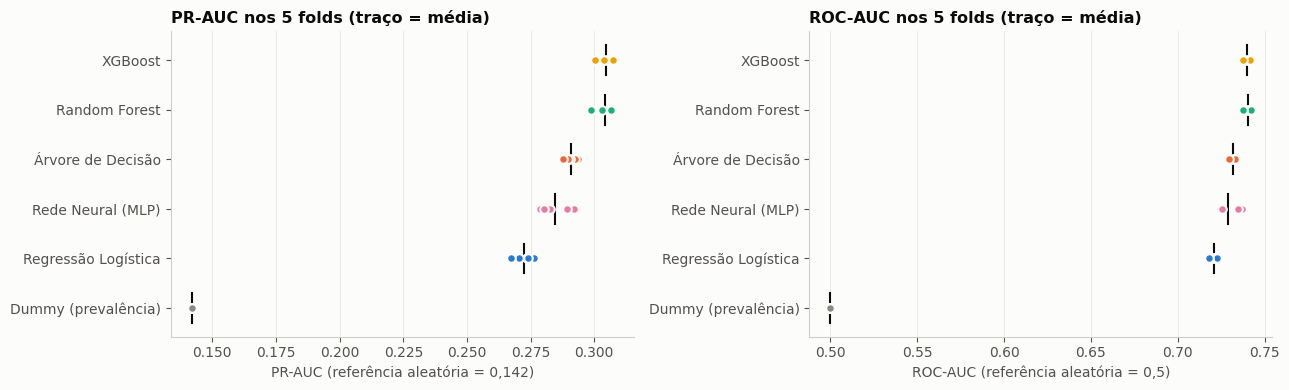

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ordem = tab_cv.index[::-1]
for ax, met in zip(axes, ["PR-AUC", "ROC-AUC"]):
    for i, nome in enumerate(ordem):
        vals = resultados_cv[nome][f"test_{met}"]
        ax.scatter(vals, [i] * len(vals), color=COR_MODELO[nome], s=38, zorder=3, edgecolor=SUPERFICIE, linewidth=1.5)
        ax.plot([vals.mean()] * 2, [i - 0.3, i + 0.3], color=TEXTO, lw=1.5)
    ax.set_yticks(range(len(ordem)), ordem)
    ax.set_title(f"{met} nos 5 folds (traço = média)")
    ax.grid(axis="y", visible=False)
axes[0].set_xlabel("PR-AUC (referência aleatória = 0,142)")
axes[1].set_xlabel("ROC-AUC (referência aleatória = 0,5)")
fig.tight_layout()
salvar(fig, "09_cv_modelos")
plt.show()

**Leitura da validação cruzada:**

* **Todos os modelos aprendem padrões nos dados sintéticos.** A PR-AUC vai de 0,142 (acaso) para 0,27–0,30, ou seja, 1,9 a 2,1 vezes a precisão de uma escolha aleatória, com desvio-padrão entre folds de apenas 0,002 a 0,005. Os resultados são estáveis.
* **Ranking:** XGBoost (0,3046) ≈ Random Forest (0,3041) > Árvore de Decisão (0,2908) > Rede Neural (0,2846) > Regressão Logística (0,2724). A diferença entre XGBoost e Random Forest (0,0005) é menor que o desvio entre folds: **desempenhos muito próximos**.
* A **Regressão Logística** fica atrás, o que é coerente com as relações não lineares observadas na EDA (1.5) e indica que modelos não lineares se ajustam melhor a estes dados.
* ***Overfitting*:** a Random Forest tem o maior gap treino−validação (0,082) e o XGBoost 0,053. Regressão Logística, MLP e Árvore (limitada a 8 níveis) têm gap próximo de zero. A Random Forest também é a mais lenta: 15,7 s por fold, contra 4,3 s do XGBoost.

### 3.4 Comparação de diferentes configurações

Três perguntas de configuração, respondidas com validação *holdout* **dentro do treino** (mesma divisão interna 80/20 da seção 2.5):

1. **Pesos de classe** (tratamento do desbalanceamento) melhoram a Regressão Logística e o XGBoost?
2. **Profundidade da árvore:** como a complexidade afeta *underfitting* e *overfitting*?
3. **Arquitetura da rede neural:** quantas camadas e neurônios?

In [25]:
Xa_tr, Xa_val, ya_tr, ya_val = X_tr.loc[tr_in], X_tr.loc[val_in], y_tr.loc[tr_in], y_tr.loc[val_in]
peso_pos = (ya_tr == 0).sum() / (ya_tr == 1).sum()


def avaliar_holdout(modelo):
    pipe = criar_pipeline(modelo).fit(Xa_tr, ya_tr)
    p_val = pipe.predict_proba(Xa_val)[:, 1]
    p_tr = pipe.predict_proba(Xa_tr)[:, 1]
    return {"PR-AUC treino": average_precision_score(ya_tr, p_tr), "PR-AUC validação": average_precision_score(ya_val, p_val),
            "ROC-AUC validação": roc_auc_score(ya_val, p_val), "Brier validação": brier_score_loss(ya_val, p_val)}


configs_peso = {
    "Regressão Logística — sem peso": LogisticRegression(C=1.0, max_iter=2000),
    "Regressão Logística — class_weight='balanced'": LogisticRegression(C=1.0, max_iter=2000, class_weight="balanced"),
    "XGBoost — sem peso": clone(modelos_base["XGBoost"]),
    f"XGBoost — scale_pos_weight={peso_pos:.1f}": clone(modelos_base["XGBoost"]).set_params(scale_pos_weight=peso_pos),
}
tab_peso = pd.DataFrame({k: avaliar_holdout(m) for k, m in configs_peso.items()}).T
display(tab_peso.round(4))

,PR-AUC treino,PR-AUC validação,ROC-AUC validação,Brier validação
Regressão Logística — sem peso,0.2726,0.2727,0.7215,0.1128
Regressão Logística — class_weight='balanced',0.2681,0.2678,0.7201,0.2180
XGBoost — sem peso,0.3586,0.3046,0.7413,0.1104
XGBoost — scale_pos_weight=6.0,0.3421,0.3054,0.7411,0.2069


**Pesos de classe não compensam.** Na Regressão Logística, `class_weight="balanced"` **piora** a PR-AUC (0,2727 → 0,2678). No XGBoost, `scale_pos_weight` dá +0,0008, dentro do ruído. Nos dois casos o **Brier score quase dobra** (≈ 0,11 → 0,21), porque os pesos inflam artificialmente as probabilidades e o modelo passa a superestimar o risco de todos. Como as faixas de risco dependem de **probabilidades confiáveis** e a ordenação dos clientes quase não muda, os modelos seguem **sem pesos**. O desbalanceamento é tratado pela escolha das métricas (PR-AUC, métricas @20 %) e pelo limiar de decisão (seção 4.4).

,PR-AUC treino,PR-AUC validação,ROC-AUC validação,Brier validação
max_depth,,,,
2,0.2376,0.2369,0.6792,0.1139
4,0.2682,0.2644,0.7154,0.1120
6,0.2886,0.2813,0.7290,0.1113
8,0.3093,0.2865,0.7300,0.1116
10,0.3382,0.2798,0.7243,0.1131
12,0.3877,0.2696,0.7156,0.1165
16,0.5407,0.2382,0.6721,0.1322
20,0.7127,0.2126,0.6243,0.1558
None,1.0000,0.1584,0.5455,0.2350


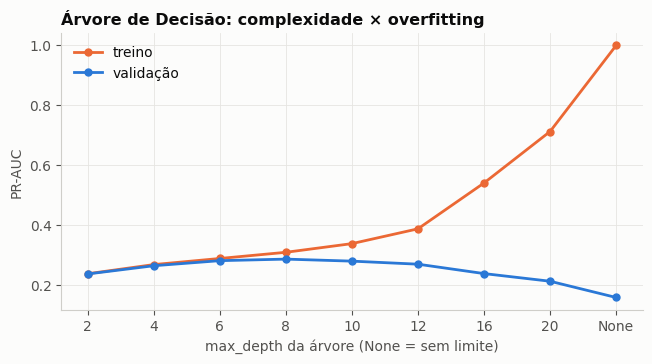

In [26]:
profundidades = [2, 4, 6, 8, 10, 12, 16, 20, None]
tab_prof = pd.DataFrame({str(d): avaliar_holdout(DecisionTreeClassifier(max_depth=d, min_samples_leaf=1, random_state=SEED))
                         for d in profundidades}).T.rename_axis("max_depth")
display(tab_prof.round(4))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
xs = range(len(profundidades))
ax.plot(xs, tab_prof["PR-AUC treino"], marker="o", ms=5, color=CORES[1], label="treino")
ax.plot(xs, tab_prof["PR-AUC validação"], marker="o", ms=5, color=CORES[0], label="validação")
ax.set_xticks(list(xs), [str(d) for d in profundidades])
ax.set_xlabel("max_depth da árvore (None = sem limite)")
ax.set_ylabel("PR-AUC")
ax.legend()
ax.set_title("Árvore de Decisão: complexidade × overfitting")
salvar(fig, "10_arvore_profundidade")
plt.show()

**Curva clássica de viés × variância.** Uma árvore rasa (`max_depth=2`) sofre *underfitting* (PR-AUC ≈ 0,24 no treino e na validação). O melhor resultado de validação está em **`max_depth=8`** (0,2865). A partir daí o treino continua subindo e a validação cai. Sem limite de profundidade, a árvore **decora** o treino (PR-AUC 1,000) e fica quase aleatória na validação (0,158). Por isso a Árvore de Decisão usa `max_depth=8` e `min_samples_leaf=200`. Os *ensembles* (Random Forest, XGBoost) fazem esse controle de complexidade de forma mais eficiente, combinando muitas árvores.

In [27]:
arquiteturas = {"1 camada (32)": (32,), "2 camadas (64, 32)": (64, 32), "3 camadas (128, 64, 32)": (128, 64, 32)}
tab_mlp = pd.DataFrame({nome: avaliar_holdout(clone(modelos_base["Rede Neural (MLP)"]).set_params(hidden_layer_sizes=cam))
                        for nome, cam in arquiteturas.items()}).T.rename_axis("arquitetura MLP")
display(tab_mlp.round(4))

,PR-AUC treino,PR-AUC validação,ROC-AUC validação,Brier validação
arquitetura MLP,,,,
1 camada (32),0.2851,0.2856,0.7303,0.1119
"2 camadas (64, 32)",0.2958,0.2939,0.7360,0.1112
"3 camadas (128, 64, 32)",0.2877,0.2854,0.7326,0.1117


**Arquitetura da rede neural.** Duas camadas (64, 32) tiveram a melhor validação (0,2939), acima de uma camada (0,2856) e de três camadas (0,2854). Mais capacidade não ajudou porque há pouco sinal adicional a extrair. Mantemos **(64, 32)** com *early stopping* e regularização L2 (`alpha=0,001`). Mesmo assim, a MLP fica abaixo dos *ensembles* de árvores e é a menos estável entre folds (dp 0,0053 na seção 3.3), resultado comum em dados tabulares.

### 3.5 Ajuste de hiperparâmetros do modelo escolhido (XGBoost)

O **XGBoost** teve a maior PR-AUC média na validação cruzada (3.3), muito próximo da Random Forest, e treina cerca de 4× mais rápido que ela. Por isso foi o modelo escolhido para ajuste fino com **`RandomizedSearchCV`** (busca aleatória com validação cruzada estratificada de 3 folds, otimizando PR-AUC). A busca aleatória cobre um espaço grande com menos treinos do que um *grid* completo. Para caber no tempo de execução, a busca usa uma **amostra estratificada de 150 mil linhas do treino**. A configuração vencedora é depois **reavaliada com a validação cruzada de 5 folds no treino inteiro**, lado a lado com o XGBoost padrão.

In [28]:
ESPACO_XGB = {
    "modelo__n_estimators": randint(200, 1200),
    "modelo__learning_rate": loguniform(0.01, 0.2),
    "modelo__max_depth": randint(3, 9),
    "modelo__min_child_weight": randint(1, 60),
    "modelo__subsample": uniform(0.6, 0.4),
    "modelo__colsample_bytree": uniform(0.4, 0.6),
    "modelo__reg_lambda": loguniform(0.1, 20),
    "modelo__gamma": uniform(0, 2),
}
amostra_busca, _ = train_test_split(X_tr.index, train_size=150_000, stratify=y_tr, random_state=SEED)
busca = RandomizedSearchCV(
    criar_pipeline(XGBClassifier(tree_method="hist", n_jobs=-1, random_state=SEED)),
    ESPACO_XGB, n_iter=30, scoring="average_precision", cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=1, refit=False, return_train_score=True)
inicio = time.time()
busca.fit(X_tr.loc[amostra_busca], y_tr.loc[amostra_busca])
print(f"Busca concluída em {time.time() - inicio:.0f}s | melhor PR-AUC (3-fold, amostra): {busca.best_score_:.4f}")

res_busca = pd.DataFrame(busca.cv_results_)
cols_param = [c for c in res_busca.columns if c.startswith("param_")]
top = res_busca.sort_values("rank_test_score")[cols_param + ["mean_test_score", "std_test_score", "mean_train_score"]].head(10)
top.columns = [c.replace("param_modelo__", "") for c in top.columns]
display(top.round(4))
MELHORES_PARAMS = {k.replace("modelo__", ""): v for k, v in busca.best_params_.items()}
print("Melhores hiperparâmetros:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in MELHORES_PARAMS.items()})

Busca concluída em 191s | melhor PR-AUC (3-fold, amostra): 0.3012


,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,mean_test_score,std_test_score,mean_train_score
16,0.6462,1.5111,0.0198,5,51,285,10.6165,0.8497,0.3012,0.0010,0.3290
1,0.6755,0.6674,0.0153,5,22,508,17.0526,0.9330,0.3011,0.0011,0.3413
2,0.5274,0.3636,0.0173,6,58,221,0.1038,0.6092,0.3009,0.0010,0.3316
19,0.6115,0.6096,0.0164,5,9,517,0.3244,0.6479,0.3005,0.0007,0.3574
14,0.8330,0.4720,0.0215,5,9,406,0.9634,0.6102,0.3004,0.0009,0.3619
25,0.9150,0.6519,0.0193,4,3,710,0.3320,0.8581,0.3004,0.0014,0.3563
18,0.8845,1.7922,0.0259,3,1,576,3.0928,0.6002,0.3003,0.0011,0.3264
24,0.6822,1.9668,0.0330,3,9,323,1.4770,0.8783,0.3001,0.0012,0.3190
22,0.7016,0.1030,0.0230,3,1,602,3.6840,0.8124,0.3000,0.0011,0.3236
20,0.6026,1.8858,0.0263,3,52,312,0.1410,0.7016,0.2998,0.0003,0.3130


Melhores hiperparâmetros: {'colsample_bytree': np.float64(0.6462), 'gamma': np.float64(1.5111), 'learning_rate': np.float64(0.0198), 'max_depth': 5, 'min_child_weight': 51, 'n_estimators': 285, 'reg_lambda': np.float64(10.6165), 'subsample': np.float64(0.8497)}


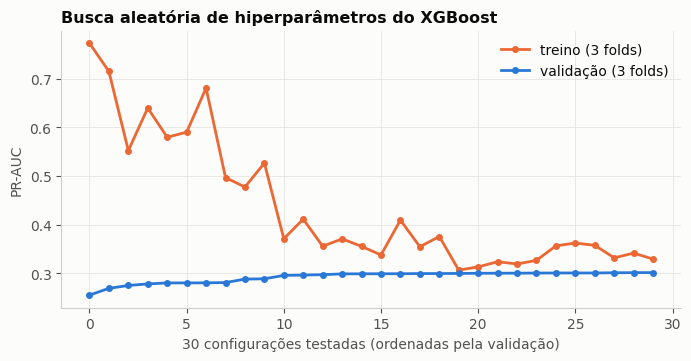

In [29]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ordem_b = res_busca.sort_values("mean_test_score").reset_index(drop=True)
ax.plot(range(len(ordem_b)), ordem_b["mean_train_score"], marker="o", ms=4, color=CORES[1], label="treino (3 folds)")
ax.plot(range(len(ordem_b)), ordem_b["mean_test_score"], marker="o", ms=4, color=CORES[0], label="validação (3 folds)")
ax.set_xlabel("30 configurações testadas (ordenadas pela validação)")
ax.set_ylabel("PR-AUC")
ax.legend()
ax.set_title("Busca aleatória de hiperparâmetros do XGBoost")
salvar(fig, "11_busca_hiperparametros")
plt.show()

In [30]:
xgb_ajustado = XGBClassifier(tree_method="hist", n_jobs=-1, random_state=SEED, **MELHORES_PARAMS)
inicio = time.time()
resultados_cv["XGBoost ajustado"] = cross_validate(criar_pipeline(xgb_ajustado), X_tr, y_tr, cv=cv5,
                                                   scoring=METRICAS_CV, return_train_score=True, n_jobs=1)
print(f"CV 5-fold do XGBoost ajustado: {time.time() - inicio:.0f}s")
tab_cv = resumo_cv(resultados_cv)
display(tab_cv.round(4))

CV 5-fold do XGBoost ajustado: 21s


,PR-AUC (média),PR-AUC (dp),ROC-AUC (média),ROC-AUC (dp),Brier (média),PR-AUC treino,gap treino−validação (PR-AUC),tempo de treino por fold (s)
modelo,,,,,,,,
XGBoost ajustado,0.3047,0.0028,0.7403,0.0016,0.1104,0.3166,0.0119,3.3318
XGBoost,0.3046,0.0024,0.7401,0.0015,0.1104,0.3579,0.0533,4.3255
Random Forest,0.3041,0.0029,0.7404,0.0016,0.1105,0.3863,0.0821,15.7249
Árvore de Decisão,0.2908,0.0020,0.7318,0.0015,0.1111,0.3016,0.0108,5.4766
Rede Neural (MLP),0.2846,0.0053,0.7291,0.0055,0.1119,0.2915,0.0069,9.9708
Regressão Logística,0.2724,0.0031,0.7209,0.0015,0.1129,0.2727,0.0003,4.0733
Dummy (prevalência),0.1419,0.0000,0.5000,0.0000,0.1218,0.1419,0.0000,2.4861


**Resultado do ajuste:**

* **Melhor configuração:** `learning_rate` 0,020, **285 árvores**, `max_depth` 5, `min_child_weight` **51**, `subsample` 0,85, `colsample_bytree` 0,65, `reg_lambda` **10,6**, `gamma` **1,51**. É bem **mais regularizada** que a configuração inicial (mais exemplos por folha, mais penalização e menos árvores).
* Na reavaliação por validação cruzada 5-fold no treino inteiro, a **PR-AUC ficou praticamente igual** (0,3047 × 0,3046). Essa reavaliação inclui as linhas usadas na busca, então **não é uma confirmação independente**. A avaliação final é feita no teste (seção 4). O **gap treino−validação observado caiu de 0,053 para 0,012 (−78 %)**, com menos árvores. Isso indica menos sobreajuste, mas não garante sozinho um desempenho futuro melhor.
* As dez melhores entre as 30 configurações avaliadas ficaram entre 0,2998 e 0,3012, com hiperparâmetros bem diferentes entre si.

### 3.6 Treinamento final
Cada modelo é re-treinado com **todo o conjunto de treino** (400 mil clientes) e só então avaliado no **teste** (seção 4).

In [31]:
modelos_finais = {nome: m for nome, m in modelos_base.items()}
modelos_finais["XGBoost ajustado"] = xgb_ajustado
pipes_finais, prob_teste = {}, {}
for nome, modelo in modelos_finais.items():
    inicio = time.time()
    pipes_finais[nome] = criar_pipeline(clone(modelo)).fit(X_tr, y_tr)
    prob_teste[nome] = pipes_finais[nome].predict_proba(X_te)[:, 1]
    print(f"{nome:22s} treinado em {time.time() - inicio:5.0f}s")

Dummy (prevalência)    treinado em     1s


Regressão Logística    treinado em     2s


Árvore de Decisão      treinado em     5s


Random Forest          treinado em    22s


XGBoost                treinado em     5s


Rede Neural (MLP)      treinado em     8s


XGBoost ajustado       treinado em     5s


<a id="4"></a>
# 4. Avaliação e comparação *(2,0 pontos)*

### 4.1 Métricas no conjunto de teste (100 mil clientes fora do treino)

In [32]:
def metricas_topk(y, p, frac=0.20):
    """Política de negócio: contatar os `frac` clientes de maior risco do lote."""
    n = int(round(len(p) * frac))
    top = np.argsort(-p)[:n]
    captura = np.asarray(y)[top].sum()
    prec = captura / n
    rec = captura / np.asarray(y).sum()
    return prec, rec, prec / np.asarray(y).mean()


linhas = []
for nome, p in prob_teste.items():
    prec20, rec20, lift20 = metricas_topk(y_te, p)
    linhas.append({"modelo": nome, "PR-AUC": average_precision_score(y_te, p), "ROC-AUC": roc_auc_score(y_te, p),
                   "Brier": brier_score_loss(y_te, p), "Log loss": log_loss(y_te, np.clip(p, 1e-6, 1 - 1e-6)),
                   "Precision@20%": prec20, "Recall@20%": rec20, "Lift@20%": lift20})
tab_teste = pd.DataFrame(linhas).set_index("modelo").sort_values("PR-AUC", ascending=False)
display(tab_teste.round(4))
tab_teste.round(4).to_csv(PASTA_FIG / "tabela_metricas_teste.csv")
tab_cv.round(4).to_csv(PASTA_FIG / "tabela_metricas_cv.csv")

,PR-AUC,ROC-AUC,Brier,Log loss,Precision@20%,Recall@20%,Lift@20%
modelo,,,,,,,
Random Forest,0.3017,0.7384,0.1107,0.3627,0.3118,0.4394,2.1970
XGBoost,0.3014,0.7381,0.1107,0.3625,0.3114,0.4388,2.1938
XGBoost ajustado,0.3007,0.7377,0.1107,0.3625,0.3104,0.4374,2.1871
Rede Neural (MLP),0.2883,0.7304,0.1118,0.3662,0.2968,0.4183,2.0917
Árvore de Decisão,0.2865,0.7279,0.1115,0.3663,0.3036,0.4278,2.1389
Regressão Logística,0.2676,0.7169,0.1132,0.3715,0.2812,0.3962,1.9810
Dummy (prevalência),0.1419,0.5000,0.1218,0.4084,0.1413,0.1991,0.9956


**Custo computacional** (importante para o *deploy*): tamanho do modelo salvo e tempo para pontuar os 100 mil clientes do teste.

In [33]:
linhas = []
for nome, pipe in pipes_finais.items():
    buffer = io.BytesIO()
    joblib.dump(pipe, buffer)
    inicio = time.perf_counter()
    pipe.predict_proba(X_te)
    linhas.append((nome, buffer.tell() / 1e6, time.perf_counter() - inicio, resultados_cv[nome]["fit_time"].mean()))
tab_custo = pd.DataFrame(linhas, columns=["modelo", "tamanho do modelo salvo (MB)", "tempo p/ pontuar 100 mil clientes (s)",
                                          "tempo de treino por fold na CV (s)"]).set_index("modelo")
display(tab_custo.round(2))

,tamanho do modelo salvo (MB),tempo p/ pontuar 100 mil clientes (s),tempo de treino por fold na CV (s)
modelo,,,
Dummy (prevalência),0.0100,0.1300,2.4900
Regressão Logística,0.0100,0.1300,4.0700
Árvore de Decisão,0.0300,0.1400,5.4800
Random Forest,55.1500,0.3500,15.7200
XGBoost,1.1200,0.2000,4.3300
Rede Neural (MLP),0.1400,0.1900,9.9700
XGBoost ajustado,0.7400,0.1800,3.3300


**Leitura dos resultados no teste:**

* O teste fica **próximo da validação cruzada** (diferenças ≤ 0,005 em PR-AUC), sem sinal de sobreajuste nas decisões tomadas no treino.
* Os três *ensembles* ficaram **muito próximos**: Random Forest 0,3017, XGBoost 0,3014 e XGBoost ajustado 0,3007. São diferenças de até 0,001, e o bootstrap pareado da seção 4.4 **não detecta diferença** entre eles. Todos superam claramente a Rede Neural (0,288), a Árvore (0,287) e a Regressão Logística (0,268).
* **Em termos de negócio:** contatando os 20 % de maior risco, a concessionária alcança **~44 % de todos os churners**, com ~31 % de acerto por contato, **2,19× melhor que escolher ao acaso** (cerca de 10 % melhor que a Regressão Logística, que tem *lift* de 1,98×). Isso mede a capacidade de **identificar** quem vai sair; o efeito das ações de retenção sobre o VIN Share precisa ser medido à parte (seção 5.4).
* **Custo:** com desempenho próximo, sem diferença detectada, o XGBoost ajustado ocupa **0,7 MB** e pontua 100 mil clientes em **0,18 s**. A Random Forest ocupa **55 MB** (75× maior) e leva **0,35 s**.
* **A escolha do modelo final não é feita pelo teste**, porque isso seria usar o teste para tomar decisões e o tornaria otimista. Ela segue a **métrica principal definida na seção 3.2** (PR-AUC média na validação cruzada), em que o XGBoost ajustado ficou à frente. O menor gap treino−validação e o menor custo operacional são argumentos adicionais (seção 5.2).

### 4.2 Curvas ROC e Precisão × Recall

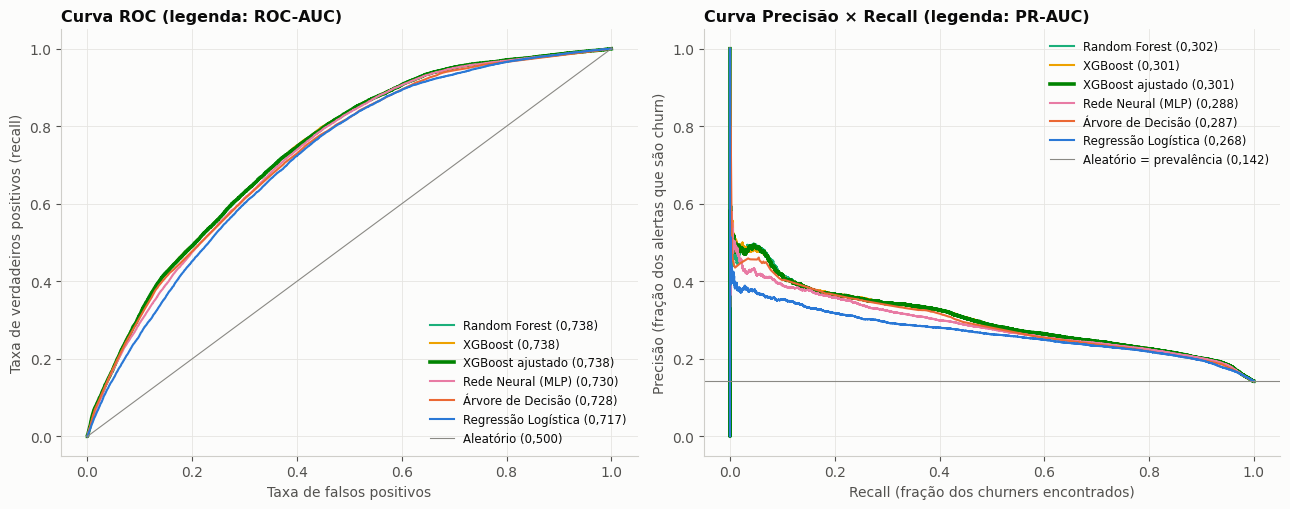

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for nome in tab_teste.index.drop("Dummy (prevalência)"):
    p = prob_teste[nome]
    destaque = nome == "XGBoost ajustado"
    fpr, tpr, _ = roc_curve(y_te, p)
    prec, rec, _ = precision_recall_curve(y_te, p)
    estilo = dict(color=COR_MODELO[nome], lw=2.6 if destaque else 1.5)
    axes[0].plot(fpr, tpr, label=f"{nome} ({br(roc_auc_score(y_te, p), 3)})", **estilo)
    axes[1].plot(rec, prec, label=f"{nome} ({br(average_precision_score(y_te, p), 3)})", **estilo)
axes[0].plot([0, 1], [0, 1], color=CINZA, lw=0.8, label="Aleatório (0,500)")
axes[0].set_xlabel("Taxa de falsos positivos")
axes[0].set_ylabel("Taxa de verdadeiros positivos (recall)")
axes[0].set_title("Curva ROC (legenda: ROC-AUC)")
axes[1].axhline(y_te.mean(), color=CINZA, lw=0.8, label=f"Aleatório = prevalência ({br(y_te.mean(), 3)})")
axes[1].set_xlabel("Recall (fração dos churners encontrados)")
axes[1].set_ylabel("Precisão (fração dos alertas que são churn)")
axes[1].set_title("Curva Precisão × Recall (legenda: PR-AUC)")
for ax in axes:
    ax.legend(fontsize=8.5, loc="lower right" if ax is axes[0] else "upper right")
fig.tight_layout()
salvar(fig, "12_curvas_roc_pr")
plt.show()

### 4.3 Curva de ganho: quantos churners a concessionária alcança?

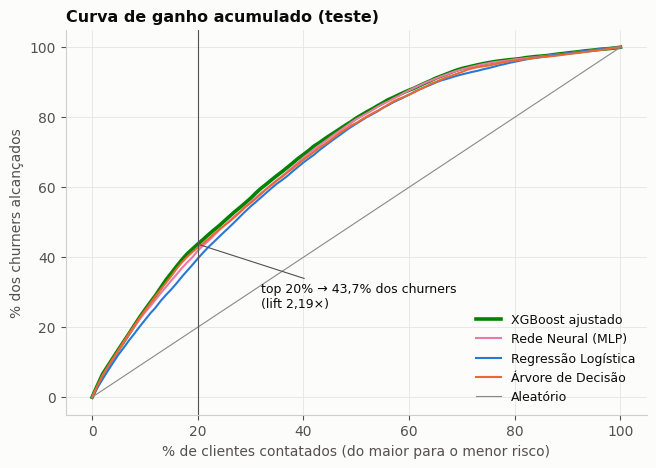

In [35]:
fig, ax = plt.subplots(figsize=(7.5, 5))
fracs = np.linspace(0, 1, 101)
for nome in ["XGBoost ajustado", "Rede Neural (MLP)", "Regressão Logística", "Árvore de Decisão"]:
    ordem_p = np.argsort(-prob_teste[nome])
    acum = np.r_[0, np.cumsum(y_te.to_numpy()[ordem_p])] / y_te.sum()
    idx = (fracs * len(ordem_p)).astype(int)
    ax.plot(fracs * 100, acum[idx] * 100, color=COR_MODELO[nome], lw=2.6 if nome == "XGBoost ajustado" else 1.5, label=nome)
ax.plot([0, 100], [0, 100], color=CINZA, lw=0.8, label="Aleatório")
ax.axvline(20, color=TEXTO_2, lw=0.8)
_, rec20_best, lift20_best = metricas_topk(y_te, prob_teste["XGBoost ajustado"])
ax.annotate(f"top 20% → {br(rec20_best * 100, 1)}% dos churners\n(lift {br(lift20_best, 2)}×)", xy=(20, rec20_best * 100),
            xytext=(32, rec20_best * 100 - 18), fontsize=9, arrowprops=dict(arrowstyle="-", color=TEXTO_2, lw=0.8))
ax.set_xlabel("% de clientes contatados (do maior para o menor risco)")
ax.set_ylabel("% dos churners alcançados")
ax.set_title("Curva de ganho acumulado (teste)")
ax.legend(loc="lower right", fontsize=9)
salvar(fig, "13_curva_ganho")
plt.show()

### 4.4 Análise detalhada do modelo selecionado (XGBoost ajustado)

**Limiar de decisão.** O modelo gera probabilidades. Para transformá-las em ações definimos **faixas de risco** com cortes calculados **nas predições *out-of-fold* do treino** (validação cruzada 5-fold), nunca no teste:
* **Alto risco:** os 10 % de maior score. Recebem contato ativo do consultor.
* **Médio risco:** os 20 % seguintes. Recebem lembretes automáticos.
* **Baixo risco:** os 70 % restantes. Recebem comunicação padrão.

Também calculamos o **limiar que maximiza o F1** (equilíbrio precisão/recall) para a matriz de confusão.

In [36]:
inicio = time.time()
oof = cross_val_predict(criar_pipeline(xgb_ajustado), X_tr, y_tr, cv=cv5, method="predict_proba", n_jobs=1)[:, 1]
print(f"Predições out-of-fold: {time.time() - inicio:.0f}s | PR-AUC OOF = {average_precision_score(y_tr, oof):.4f}")
CORTE_ALTO = float(np.quantile(oof, 0.90))
CORTE_MEDIO = float(np.quantile(oof, 0.70))
prec_c, rec_c, lim_c = precision_recall_curve(y_tr, oof)
f1_c = 2 * prec_c * rec_c / np.clip(prec_c + rec_c, 1e-12, None)
LIMIAR_F1 = float(lim_c[np.argmax(f1_c[:-1])])
print(f"Corte alto risco (p90 OOF) = {CORTE_ALTO:.4f} | corte médio risco (p70 OOF) = {CORTE_MEDIO:.4f} | "
      f"limiar F1-ótimo = {LIMIAR_F1:.4f}")

Predições out-of-fold: 18s | PR-AUC OOF = 0.3045
Corte alto risco (p90 OOF) = 0.3037 | corte médio risco (p70 OOF) = 0.1799 | limiar F1-ótimo = 0.1790


Classificação no teste com limiar F1-ótimo (0.179):

               precision    recall  f1-score   support

Permanece (0)      0.913     0.740     0.817     85808
    Churn (1)      0.268     0.576     0.366     14192

     accuracy                          0.716    100000
    macro avg      0.591     0.658     0.591    100000
 weighted avg      0.822     0.716     0.753    100000



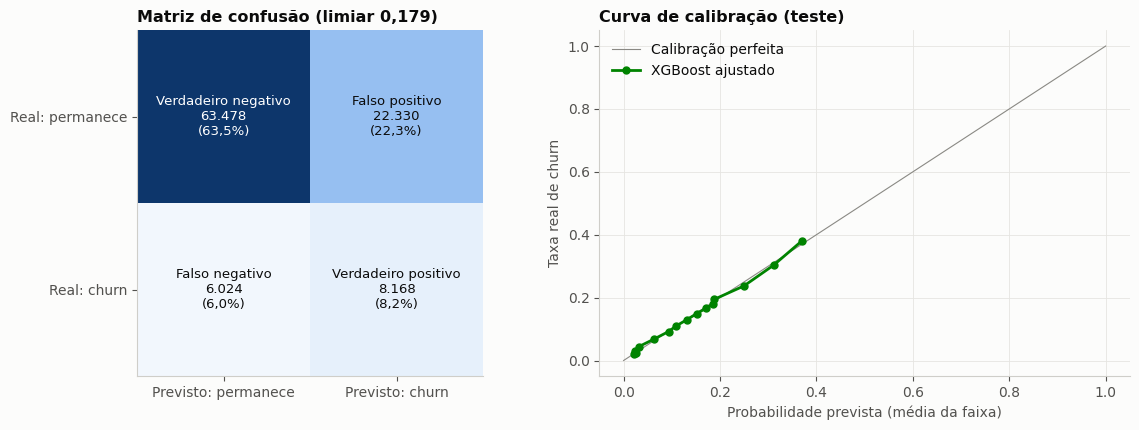

In [37]:
p_best = prob_teste["XGBoost ajustado"]
pred_best = (p_best >= LIMIAR_F1).astype(int)
print(f"Classificação no teste com limiar F1-ótimo ({LIMIAR_F1:.3f}):\n")
print(classification_report(y_te, pred_best, target_names=["Permanece (0)", "Churn (1)"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
cm = confusion_matrix(y_te, pred_best)
axes[0].imshow(cm, cmap=CMAP_SEQ)
axes[0].grid(False)
rotulos = [["Verdadeiro negativo", "Falso positivo"], ["Falso negativo", "Verdadeiro positivo"]]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{rotulos[i][j]}\n{br(cm[i, j], 0)}\n({br(cm[i, j] / cm.sum() * 100, 1)}%)", ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() * 0.5 else TEXTO, fontsize=9.5)
axes[0].set_xticks([0, 1], ["Previsto: permanece", "Previsto: churn"])
axes[0].set_yticks([0, 1], ["Real: permanece", "Real: churn"])
axes[0].set_title(f"Matriz de confusão (limiar {br(LIMIAR_F1, 3)})")

frac_pred, frac_real = calibration_curve(y_te, p_best, n_bins=15, strategy="quantile")
axes[1].plot([0, 1], [0, 1], color=CINZA, lw=0.8, label="Calibração perfeita")
axes[1].plot(frac_pred, frac_real, marker="o", ms=5, color=COR_MODELO["XGBoost ajustado"], label="XGBoost ajustado")
axes[1].set_xlabel("Probabilidade prevista (média da faixa)")
axes[1].set_ylabel("Taxa real de churn")
axes[1].set_title("Curva de calibração (teste)")
axes[1].legend(loc="upper left")
fig.tight_layout()
salvar(fig, "14_confusao_calibracao")
plt.show()

* **Matriz de confusão (limiar F1-ótimo = 0,179, calculado no treino):** o modelo identifica **57,6 % dos churners** (*recall*) e **26,8 %** dos alertados de fato saem (*precision*), com F1 = 0,366. Esse limiar é baixo de propósito. Em retenção, **deixar escapar um churner** (falso negativo, perda de receita de pós-venda) custa mais do que **um contato a mais** com quem ficaria (falso positivo: um lembrete ou uma ligação). A acurácia (71,6 %) não é usada para decidir por causa do desbalanceamento.
* **Calibração:** a curva acompanha a diagonal. Quando o modelo diz "30 % de risco", cerca de 30 % desses clientes realmente saem. Por isso as **probabilidades podem ser mostradas diretamente** no app da concessionária e usadas para definir faixas (Brier 0,1107 × 0,1218 do Dummy).

In [38]:
faixa_te = np.select([p_best >= CORTE_ALTO, p_best >= CORTE_MEDIO], ["1. Alto", "2. Médio"], "3. Baixo")
tab_faixas = (pd.DataFrame({"faixa": faixa_te, "churn": y_te.to_numpy()})
              .groupby("faixa").agg(clientes=("churn", "size"), churners=("churn", "sum"), taxa_churn=("churn", "mean")))
tab_faixas["% dos clientes"] = tab_faixas["clientes"] / tab_faixas["clientes"].sum() * 100
tab_faixas["% dos churners"] = tab_faixas["churners"] / tab_faixas["churners"].sum() * 100
tab_faixas["taxa_churn"] *= 100
tab_faixas["lift vs média"] = tab_faixas["taxa_churn"] / (y_te.mean() * 100)
display(tab_faixas.round(2))

,clientes,churners,taxa_churn,% dos clientes,% dos churners,lift vs média
faixa,,,,,,
1. Alto,10084,3572,35.4200,10.0800,25.1700,2.5000
2. Médio,20000,4511,22.5600,20.0000,31.7900,1.5900
3. Baixo,69916,6109,8.7400,69.9200,43.0500,0.6200


**Faixas de risco no teste (cortes definidos no treino):**

| Faixa | % dos clientes | Taxa de churn | vs. média | % de todos os churners |
|---|---|---|---|---|
| **Alto** | 10,1 % | **35,4 %** | 2,50× | 25,2 % |
| **Médio** | 20,0 % | 22,6 % | 1,59× | 31,8 % |
| **Baixo** | 69,9 % | 8,7 % | 0,62× | 43,0 % |

As faixas **Alto + Médio** (30 % da carteira) concentram **57 % dos clientes que vão sair**. A concessionária pode concentrar o esforço de retenção nesses 30 %, e os cortes aprendidos no treino reproduzem no teste as proporções planejadas (10 % e 20 %).

**Estabilidade e *overfitting*: treino × validação cruzada × teste, com intervalo de confiança (bootstrap).**

In [39]:
p_treino_best = pipes_finais["XGBoost ajustado"].predict_proba(X_tr)[:, 1]
estab = pd.DataFrame({
    "PR-AUC": [average_precision_score(y_tr, p_treino_best), tab_cv.loc["XGBoost ajustado", "PR-AUC (média)"], tab_teste.loc["XGBoost ajustado", "PR-AUC"]],
    "ROC-AUC": [roc_auc_score(y_tr, p_treino_best), tab_cv.loc["XGBoost ajustado", "ROC-AUC (média)"], tab_teste.loc["XGBoost ajustado", "ROC-AUC"]],
}, index=["treino (ajuste)", "validação cruzada 5-fold", "teste"])
display(estab.round(4))

rng = np.random.default_rng(SEED)
CONCORRENTES = ["Random Forest", "XGBoost"]  # os dois modelos com desempenho mais próximo do selecionado
y_np = y_te.to_numpy()
boot = []
for _ in range(300):
    i = rng.integers(0, len(y_np), len(y_np))
    ap_best = average_precision_score(y_np[i], p_best[i])
    boot.append([ap_best, roc_auc_score(y_np[i], p_best[i])]
                + [ap_best - average_precision_score(y_np[i], prob_teste[c][i]) for c in CONCORRENTES])
boot = np.array(boot)
ic = pd.DataFrame(np.percentile(boot, [2.5, 50, 97.5], axis=0).T,
                  index=["PR-AUC (XGBoost ajustado)", "ROC-AUC (XGBoost ajustado)"]
                        + [f"Diferença de PR-AUC: XGBoost ajustado − {c}" for c in CONCORRENTES],
                  columns=["IC 2,5%", "mediana", "IC 97,5%"])
display(ic.round(4))

,PR-AUC,ROC-AUC
treino (ajuste),0.3150,0.7462
validação cruzada 5-fold,0.3047,0.7403
teste,0.3007,0.7377


,"IC 2,5%",mediana,"IC 97,5%"
PR-AUC (XGBoost ajustado),0.2945,0.3010,0.3074
ROC-AUC (XGBoost ajustado),0.7336,0.7378,0.7416
Diferença de PR-AUC: XGBoost ajustado − Random Forest,-0.0023,-0.0010,0.0005
Diferença de PR-AUC: XGBoost ajustado − XGBoost,-0.0023,-0.0007,0.0010


* **Queda pequena do treino para dados não vistos:** PR-AUC de 0,315 no treino, 0,305 na validação cruzada e 0,301 no teste, sem sinal de *overfitting* relevante.
* **Intervalo de confiança de 95 % (bootstrap, 300 reamostragens do teste):** PR-AUC entre **0,294 e 0,307** e ROC-AUC entre **0,734 e 0,742**.
* **Nenhuma diferença detectada:** os intervalos das diferenças de PR-AUC entre o XGBoost ajustado e a Random Forest (−0,0023 a 0,0005) e o XGBoost padrão (−0,0023 a 0,0010) **incluem o zero**. O bootstrap pareado não detecta diferença entre os três, o que não prova que sejam equivalentes.

### 4.5 Interpretação: o que leva o cliente a sair da rede?
Valores **SHAP** (contribuição de cada variável para o score de cada cliente) calculados em uma amostra de 5 mil clientes do teste.

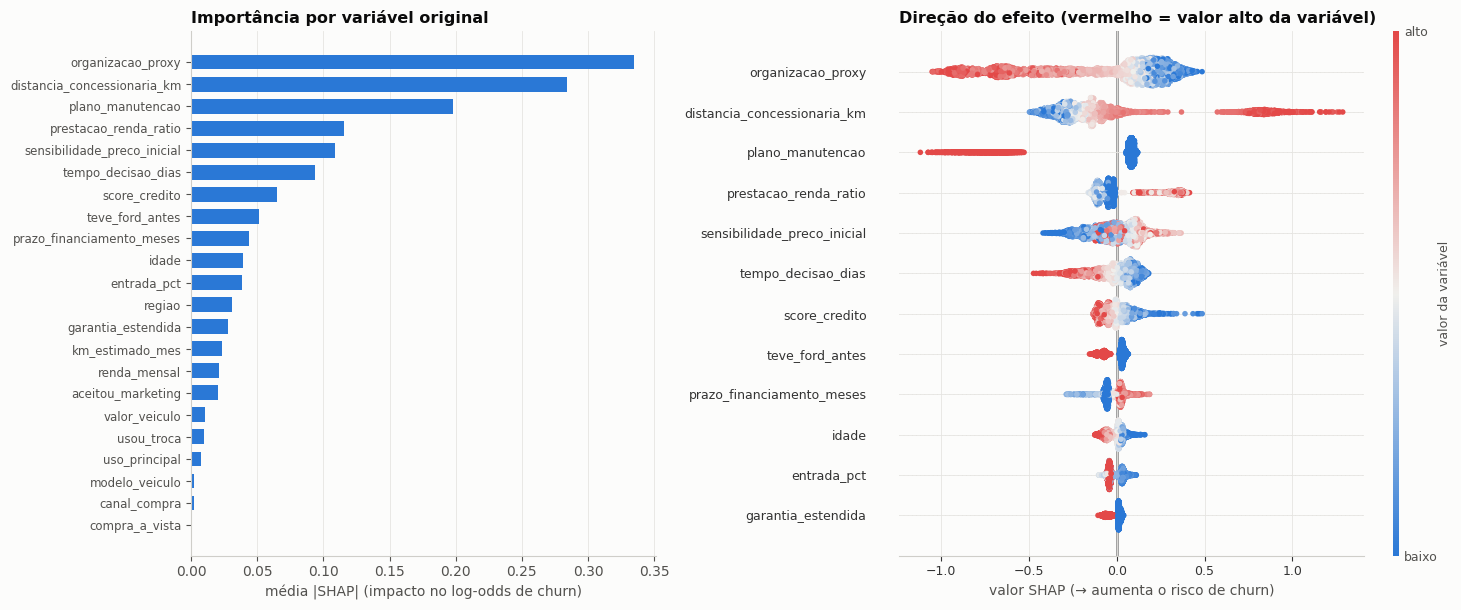

In [40]:
pipe_best = pipes_finais["XGBoost ajustado"]
modelo_best = pipe_best.named_steps["modelo"]
amostra_shap = X_te.sample(5000, random_state=SEED)
# todo o pré-processamento (correção + ColumnTransformer), exatamente como na predição
Xs = pd.DataFrame(pipe_best[:-1].transform(amostra_shap), columns=pipe_best.named_steps["prep"].get_feature_names_out())
valores_shap = shap.TreeExplainer(modelo_best).shap_values(Xs)


def variavel_original(coluna):
    for c in CATEGORICAS:
        if coluna.startswith(c + "_"):
            return c
    return coluna


imp = (pd.DataFrame(np.abs(valores_shap), columns=Xs.columns).T.groupby(variavel_original).sum().T.mean()
       .sort_values(ascending=True))
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), gridspec_kw={"width_ratios": [1, 1.25]})
axes[0].barh(imp.index, imp.values, color=CORES[0], height=0.65)
axes[0].set_xlabel("média |SHAP| (impacto no log-odds de churn)")
axes[0].set_title("Importância por variável original")
axes[0].grid(axis="y", visible=False)
axes[0].tick_params(axis="y", labelsize=8.5)
plt.sca(axes[1])
shap.summary_plot(valores_shap, Xs, max_display=12, show=False, plot_size=None, cmap=CMAP_DIV)
axes[1].set_title("Direção do efeito (vermelho = valor alto da variável)", fontsize=11.5, fontweight="bold", loc="left")
axes[1].set_xlabel("valor SHAP (→ aumenta o risco de churn)", fontsize=10, color=TEXTO_2)
axes[1].tick_params(axis="y", labelsize=9)
axes[1].tick_params(axis="x", labelsize=9)
barra_cor = fig.axes[-1]
barra_cor.set_ylabel("valor da variável", fontsize=9, color=TEXTO_2)
barra_cor.set_yticklabels(["baixo", "alto"], fontsize=9)
fig.tight_layout()
salvar(fig, "15_shap")
plt.show()

**O que o modelo aprendeu (coerente com a EDA e com o negócio) e o que a concessionária pode fazer:**

| Fator de risco (SHAP) | Efeito no risco de churn | Ação sugerida para a concessionária |
|---|---|---|
| Baixa `organizacao_proxy` | ↑ forte | lembretes automáticos e agendamento da 1ª revisão já na entrega do carro |
| Grande `distancia_concessionaria_km` | ↑ forte (principalmente acima de ~40 km) | leva-e-traz, revisão em unidade móvel, indicar a concessionária Ford mais próxima |
| Sem `plano_manutencao` | ↑ forte (quem tem plano quase não sai) | oferecer plano de manutenção/revisão com preço fechado **no momento da venda** |
| `prestacao_renda_ratio` alta | ↑ | revisão parcelada ou com preço fixo; mostrar o custo total previsível |
| `sensibilidade_preco_inicial` alta | ↑ | combos de revisão, cashback, preço competitivo com oficinas independentes |
| `tempo_decisao_dias` baixo, `score_credito` baixo, cliente novo na Ford, mais jovem | ↑ moderado | programa de boas-vindas e de relacionamento pós-venda |

Todas as direções batem com a EDA (seção 1.5). O modelo não depende de artefatos: `modelo_veiculo`, `canal_compra` e `compra_a_vista` têm peso quase nulo quando as outras variáveis são conhecidas.

### 4.6 Robustez por segmento e checagem de sanidade

In [41]:
linhas = []
for col in ["regiao", "categoria_veiculo", "canal_compra"]:
    for valor, grupo in teste.groupby(col):
        m = teste[col] == valor
        linhas.append((col, valor, m.sum(), y_te[m].mean() * 100, roc_auc_score(y_te[m], p_best[m]),
                       average_precision_score(y_te[m], p_best[m])))
seg = pd.DataFrame(linhas, columns=["variável", "segmento", "clientes", "% churn", "ROC-AUC", "PR-AUC"]).set_index(["variável", "segmento"])
display(seg.round(3))

sanidade = (pd.DataFrame({"perfil_latente": teste["perfil_latente"], "score": p_best, "churn": y_te})
            .groupby("perfil_latente").agg(clientes=("churn", "size"), churn_real=("churn", "mean"), score_medio=("score", "mean"),
                                           pct_em_alto_risco=("score", lambda s: (s >= CORTE_ALTO).mean()))
            .sort_values("score_medio", ascending=False))
sanidade[["churn_real", "score_medio", "pct_em_alto_risco"]] *= 100
display(sanidade.round(2))

clientes  % churn  ROC-AUC  PR-AUC
variável          segmento                                         
regiao            capital           33014  11.3070   0.7620  0.2840
                  interior          32516  17.2960   0.7030  0.3120
                  metropolitana     34470  14.0270   0.7350  0.3000
categoria_veiculo hatch             26218  13.9220   0.7010  0.2640
                  picape            24027  15.2870   0.7600  0.3370
                  sedan             20145  13.2090   0.7310  0.2710
                  suv               22826  13.1170   0.7480  0.2920
                  van                6784  17.8950   0.7310  0.3550
canal_compra      frota              9605  13.9200   0.7190  0.2960
                  loja              61516  13.6310   0.7450  0.2970
                  online            19769  15.0640   0.7320  0.3050
                  telefone           9110  16.3780   0.7130  0.3180

,clientes,churn_real,score_medio,pct_em_alto_risco
perfil_latente,,,,
abandono,24060,27.5000,23.4600,29.0600
esquecido,20047,20.8500,20.8600,13.6000
economico,25858,10.3400,12.5700,1.4000
fiel,30035,2.4100,3.7400,0.0100


* **Robustez:** a ROC-AUC fica entre **0,70 (hatch/interior) e 0,76 (capital/picape)** em todas as regiões, categorias e canais. Não há segmento em que o modelo deixe de funcionar. Os segmentos de menor desempenho (interior, hatch) são pontos de atenção para o monitoramento em produção.
* **Checagem de sanidade com o perfil latente** (nunca usado no treino): o score médio segue **exatamente a ordem real** de churn dos perfis. *Abandono* tem score 23,5 % (real 27,5 %), *esquecido* 20,9 % (20,9 %), *econômico* 12,6 % (10,3 %) e *fiel* 3,7 % (2,4 %). **29 % dos clientes "abandono" caem na faixa Alta, contra 0,01 % dos "fiéis".** Só com dados da compra, o score reproduz a ordem de risco dos perfis ocultos.

<a id="5"></a>
# 5. Conclusão *(1,5 ponto — item 6 do enunciado)*

### 5.1 Modelo selecionado: **XGBoost ajustado**

Pipeline completo = correção de inconsistências → winsorização → imputação → log/padronização → *one-hot* → **XGBoost** (285 árvores, `max_depth` 5, `learning_rate` 0,020, regularizado), usando as **22 variáveis disponíveis no momento da compra**.

### 5.2 Justificativa da escolha

| Critério | XGBoost ajustado | XGBoost padrão | Random Forest |
|---|---|---|---|
| **PR-AUC na validação cruzada** (métrica principal, seção 3.2) | **0,3047** | 0,3046 | 0,3041 |
| Gap treino−validação (*overfitting*) | **0,012** | 0,053 | 0,082 |
| PR-AUC no teste (sem diferença detectada, seção 4.4) | 0,3007 | 0,3014 | 0,3017 |
| Tamanho do modelo salvo | **0,7 MB** | 1,1 MB | 55 MB |
| Tempo para pontuar 100 mil clientes | **0,18 s** | 0,20 s | 0,35 s |
| Tempo de treino por fold | **3,3 s** | 4,3 s | 15,7 s |

1. **Maior PR-AUC média na validação cruzada**, a métrica principal definida na seção 3.2. No teste, o bootstrap pareado não detectou diferença para o XGBoost padrão e a Random Forest.
2. **Menor gap treino−validação observado** entre os *ensembles* (0,012): a regularização encontrada no ajuste reduziu o gap treino−validação observado em 78 %.
3. **Mais leve para produção:** artefato pequeno e predição rápida, adequados a uma API em tempo real. Re-treinar é barato.
4. **Probabilidades calibradas** (curva de calibração sobre a diagonal): permitem mostrar o risco em % e definir faixas de ação.
5. **Explicável:** os valores SHAP mostram por que cada cliente recebeu seu score, o que é importante para o vendedor confiar no lead e para a transparência com o cliente (LGPD).

### Principais resultados

* **PR-AUC 0,301** no teste (2,1× o acaso de 0,142) e **ROC-AUC 0,738**, estáveis entre treino, validação cruzada e teste.
* **Top 20 % de risco → 43,7 % dos churners** (*lift* 2,19×). Faixa **Alta** (10 % dos clientes) → **35,4 %** de churn (2,5× a média). Faixas Alta + Média (30 % dos clientes) → **57 %** dos churners.
* Principais fatores de risco: **baixa organização, distância da concessionária, ausência de plano de manutenção, parcela alta em relação à renda e sensibilidade a preço**. Todos são acionáveis pela concessionária.
* **Métricas honestas:** rejeitamos um modelo com PR-AUC 0,458 porque ele usava informações que só existem depois da venda (vazamento). O modelo entregue funciona com os dados que a Ford realmente tem quando precisa agir.

### 5.3 Como o modelo é usado na aplicação da Ford e forma de *deploy*

**Fluxo proposto (pontuação no momento da venda):**

```
 ┌────────────────────┐   venda registrada    ┌──────────────────────────────┐   score + faixa   ┌─────────────────────────────┐
 │ DMS / CRM da       │ ───────────────────►  │ API de scoring (REST + JWT)  │ ────────────────► │ App / dashboard da          │
 │ concessionária     │  layout do arquivo    │ POST /api/v1/churn/score     │                   │ concessionária: lista de    │
 │ (dados da compra)  │  operacional_compra   │ carrega modelo .joblib       │                   │ leads priorizada + ação     │
 └────────────────────┘                       └──────────────┬───────────────┘                   └─────────────────────────────┘
                                                             │ logs de score + desfecho (24 meses)
                                                             ▼
                                              ┌──────────────────────────────┐
                                              │ Monitoramento e re-treino    │
                                              │ (drift, PR-AUC, conversão)   │
                                              └──────────────────────────────┘
```

1. **Empacotamento:** o `Pipeline` completo (correção de inconsistências + pré-processamento + XGBoost) é salvo em um único arquivo `.joblib` com a lista de variáveis, os cortes das faixas e as métricas. O código de pré-processamento fica no módulo `ford_churn_pipeline.py`, que acompanha o artefato. Assim, a produção aplica **exatamente** as mesmas transformações do treino.
2. **Serviço:** uma API REST (por exemplo, FastAPI em contêiner Docker na nuvem) expõe `POST /api/v1/churn/score`, protegida por JWT (a mesma camada de API/segurança do projeto). A API recebe os campos do layout `operacional_compra` e devolve probabilidade, faixa de risco e ação sugerida. A predição leva milissegundos por cliente.
3. **Dois modos de uso:** (a) **tempo real**, quando o vendedor fecha a venda e o app já mostra o risco e a ação recomendada; (b) **lote diário**, um *job* noturno que pontua as vendas do dia e alimenta a fila de leads do pós-venda.
4. **Integração com a jornada do cliente:** faixa **Alta** vira contato do consultor + oferta de plano de manutenção/revisão com preço fechado. Faixa **Média** vira lembretes automáticos (app, WhatsApp, e-mail) e agendamento online. Faixa **Baixa** recebe comunicação padrão.
5. **Monitoramento (MLOps):** acompanhar o *drift* das variáveis de entrada (PSI), a distribuição dos scores e, quando os desfechos de 24 meses chegam, a PR-AUC real. Re-treinar periodicamente (ex.: semestral) ou quando o *drift* passar do limite. Versionar os modelos (ex.: MLflow).

**Simulação do deploy:** salvamos o artefato e (i) pontuamos um lote no **layout exato do arquivo `operacional_compra`** (dados crus, incluindo registros com prazo 0 e com campos ausentes), como a API faria. Depois (ii) o **artefato de inferência é carregado e validado em um processo Python separado**, sem o notebook, a partir do CSV operacional cru, nas versões documentadas em `requirements.txt`, para integração à API proposta. Usamos só clientes do **conjunto de teste**.

In [42]:
artefato = {
    "pipeline": pipes_finais["XGBoost ajustado"],
    "features": FEATURES,
    "cortes": {"alto": CORTE_ALTO, "medio": CORTE_MEDIO},
    "hiperparametros": MELHORES_PARAMS,
    "metricas_teste": tab_teste.loc["XGBoost ajustado"].round(4).to_dict(),
    "versoes": {"scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__},
}
caminho_modelo = PASTA_MODELO / "modelo_churn_rede_ford.joblib"
joblib.dump(artefato, caminho_modelo)
print(f"Artefato salvo em {caminho_modelo} ({caminho_modelo.stat().st_size / 1e6:.1f} MB)")

ACOES = {"Alto": "Contato ativo do consultor + oferta de plano de manutenção",
         "Médio": "Lembretes automáticos de revisão + agendamento online",
         "Baixo": "Comunicação padrão de pós-venda"}


def pontuar_clientes(lote_operacional, artefato):
    """O que a API de scoring faz: recebe registros crus no layout do arquivo operacional e devolve os leads."""
    p = artefato["pipeline"].predict_proba(lote_operacional[artefato["features"]])[:, 1]  # cliente_id fica fora
    faixa = np.select([p >= artefato["cortes"]["alto"], p >= artefato["cortes"]["medio"]], ["Alto", "Médio"], "Baixo")
    return (pd.DataFrame({"cliente_id": lote_operacional["cliente_id"].to_numpy(),
                          "modelo_veiculo": lote_operacional["modelo_veiculo"].to_numpy(),
                          "prazo_0_financiado": ((lote_operacional["compra_a_vista"] == 0)
                                                 & (lote_operacional["prazo_financiamento_meses"] == 0)).to_numpy(),
                          "campos_ausentes": lote_operacional[artefato["features"]].isna().sum(axis=1).to_numpy(),
                          "prob_churn_24m": p.round(3), "faixa_risco": faixa, "acao_sugerida": pd.Series(faixa).map(ACOES).values})
            .sort_values("prob_churn_24m", ascending=False).reset_index(drop=True))


oper_teste = oper.loc[idx_teste]  # dados CRUS do arquivo operacional (mesmos clientes do teste)
prazo0 = oper_teste[(oper_teste.compra_a_vista == 0) & (oper_teste.prazo_financiamento_meses == 0)]
com_ausentes = oper_teste[oper_teste[FEATURES].isna().any(axis=1)]
lote = pd.concat([prazo0.head(3), com_ausentes.head(3),
                  oper_teste.drop(prazo0.index.union(com_ausentes.index)).sample(6, random_state=7)])
print("Colunas recebidas pela 'API' (layout operacional cru):", list(lote.columns)[:6], "...")
display(pontuar_clientes(lote, joblib.load(caminho_modelo)))

Artefato salvo em C:\Users\lucca\Downloads\Sprint-ML3\entrega\modelo\modelo_churn_rede_ford.joblib (0.7 MB)
Colunas recebidas pela 'API' (layout operacional cru): ['cliente_id', 'idade', 'renda_mensal', 'score_credito', 'distancia_concessionaria_km', 'regiao'] ...


,cliente_id,modelo_veiculo,prazo_0_financiado,campos_ausentes,prob_churn_24m,faixa_risco,acao_sugerida
0,477586,Focus Hatch,False,0,0.3060,Alto,Contato ativo do consultor + oferta de plano d...
1,124851,Ka Sedan,False,0,0.2190,Médio,Lembretes automáticos de revisão + agendamento...
2,246567,F-150,False,0,0.1820,Médio,Lembretes automáticos de revisão + agendamento...
3,323956,Ka,False,0,0.1660,Baixo,Comunicação padrão de pós-venda
4,453973,EcoSport,False,0,0.1370,Baixo,Comunicação padrão de pós-venda
5,489817,Territory,False,0,0.1190,Baixo,Comunicação padrão de pós-venda
6,48717,Maverick,False,1,0.0970,Baixo,Comunicação padrão de pós-venda
7,61585,Maverick,False,1,0.0890,Baixo,Comunicação padrão de pós-venda
8,240367,EcoSport,True,0,0.0420,Baixo,Comunicação padrão de pós-venda
9,29610,Ka Sedan,True,0,0.0330,Baixo,Comunicação padrão de pós-venda


**Validação em processo Python separado.** O script abaixo (salvo em `modelo/validar_artefato.py`) roda num processo novo que **não importa o notebook**: só `joblib`, as bibliotecas e o módulo `ford_churn_pipeline.py`. Ele lê o **CSV operacional cru**, pontua os clientes pedidos e grava as probabilidades. O lote de validação inclui **todos** os financiamentos com prazo 0 do teste, 300 registros com campos ausentes e 2.000 clientes aleatórios do teste.

In [43]:
%%writefile modelo/validar_artefato.py
"""Valida o artefato de inferência num processo Python separado (sem o notebook).
Uso: python validar_artefato.py <pasta_do_modulo> <modelo.joblib> <csv_operacional> <ids.csv> <saida.csv>"""
import sys

import joblib
import pandas as pd

pasta_modulo, caminho_modelo, csv_operacional, csv_ids, csv_saida = sys.argv[1:6]
sys.path.insert(0, pasta_modulo)  # onde está ford_churn_pipeline.py
artefato = joblib.load(caminho_modelo)
ids = pd.read_csv(csv_ids)["cliente_id"]
operacional = pd.read_csv(csv_operacional)  # layout operacional cru, sem nenhum tratamento
lote = operacional[operacional["cliente_id"].isin(ids)]
prob = artefato["pipeline"].predict_proba(lote[artefato["features"]])[:, 1]
pd.DataFrame({"cliente_id": lote["cliente_id"].to_numpy(), "prob": prob}).to_csv(csv_saida, index=False, float_format="%.17g")
winsor = artefato["pipeline"].named_steps["prep"].named_transformers_["assim"].named_steps["winsor"]
print(f"processo separado OK | {len(lote)} clientes pontuados | Winsorizer carregado do módulo: {type(winsor).__module__}")

Overwriting modelo/validar_artefato.py


In [44]:
lote_validacao = pd.concat([prazo0, com_ausentes.sample(300, random_state=SEED),
                            oper_teste.sample(2000, random_state=SEED)]).drop_duplicates("cliente_id")
arq_ids, arq_pred = PASTA_MODELO / "_ids_validacao.csv", PASTA_MODELO / "_pred_processo_separado.csv"
lote_validacao[["cliente_id"]].to_csv(arq_ids, index=False)
saida = subprocess.run([sys.executable, str(PASTA_MODELO / "validar_artefato.py"), str(BASE), str(caminho_modelo),
                        str(achar_arquivo("ford_clientes_operacional_compra.csv")), str(arq_ids), str(arq_pred)],
                       capture_output=True, text=True, check=True)
print(saida.stdout.strip())

pred_separado = pd.read_csv(arq_pred).set_index("cliente_id")["prob"]
p_teste_por_id = pd.Series(p_best.astype(float), index=teste["cliente_id"].to_numpy())
comparacao = pd.DataFrame({"processo_separado": pred_separado, "avaliado_no_teste": p_teste_por_id.loc[pred_separado.index]})
dif_max = float((comparacao["processo_separado"] - comparacao["avaliado_no_teste"]).abs().max())
VALIDACAO_DEPLOY = {
    "populacao": "teste (layout operacional cru)", "clientes": int(len(comparacao)),
    "financiados_prazo_0": int(len(prazo0)), "com_campos_ausentes": int(lote_validacao[FEATURES].isna().any(axis=1).sum()),
    "maior_diferenca_absoluta": dif_max, "tolerancia": 1e-12,
    "ok": bool(np.allclose(comparacao["processo_separado"], comparacao["avaliado_no_teste"], atol=1e-12, rtol=0)),
}
display(pd.Series(VALIDACAO_DEPLOY).astype(str).to_frame("validação do artefato em processo separado"))
assert VALIDACAO_DEPLOY["ok"], "o artefato carregado fora do notebook não reproduz as predições avaliadas no teste"
arq_ids.unlink()
arq_pred.unlink()

processo separado OK | 2353 clientes pontuados | Winsorizer carregado do módulo: ford_churn_pipeline


,validação do artefato em processo separado
populacao,teste (layout operacional cru)
clientes,2353
financiados_prazo_0,63
com_campos_ausentes,532
maior_diferenca_absoluta,1.1102230246251565e-16
tolerancia,1e-12
ok,True


Exemplo de contrato da API (JSON):

```json
POST /api/v1/churn/score          Authorization: Bearer <JWT>
{"cliente_id": 123, "idade": 41, "renda_mensal": 9800.0, "score_credito": 712, "distancia_concessionaria_km": 32.5,
 "regiao": "interior", "uso_principal": "trabalho", "km_estimado_mes": 2100, "modelo_veiculo": "Ranger", ...}

200 OK
{"cliente_id": 123, "prob_churn_24m": 0.41, "faixa_risco": "Alto",
 "acao_sugerida": "Contato ativo do consultor + oferta de plano de manutenção", "versao_modelo": "1.0.0"}
```

**Registro dos resultados:** as tabelas principais são gravadas em `figuras/resumo_resultados.json`, cada uma com a população de origem (treino, teste ou base completa). Os resultados quantitativos da documentação em PDF são extraídos desse arquivo.

In [45]:
def registros(df):
    return json.loads(df.reset_index().to_json(orient="records", force_ascii=False))


resumo = {
    "ablacao": registros(ablacao), "variaveis_criadas": registros(tab_fe), "cv": registros(tab_cv),
    "teste": registros(tab_teste), "pesos_classe": registros(tab_peso), "arvore_profundidade": registros(tab_prof),
    "mlp_arquiteturas": registros(tab_mlp), "busca_top10": registros(top), "estabilidade": registros(estab),
    "ic_bootstrap": registros(ic), "faixas_risco": registros(tab_faixas), "segmentos": registros(seg),
    "sanidade_perfil_latente": registros(sanidade),
    "importancia_shap": {k: float(v) for k, v in imp.sort_values(ascending=False).items()},
    "melhores_params": {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in MELHORES_PARAMS.items()},
    "cortes": {"alto": CORTE_ALTO, "medio": CORTE_MEDIO, "limiar_f1": LIMIAR_F1},
    "custo": registros(tab_custo), "n_treino": int(len(treino)), "n_teste": int(len(teste)),
    "taxa_churn": float(TAXA_GERAL), "features": FEATURES,
    "eda": EDA, "ausentes": registros(tab_na), "inconsistencias": registros(checagens), "outliers": registros(tab_out),
    "prestacao_formula": PRESTACAO, "estrutura": ESTRUTURA, "validacao_deploy": VALIDACAO_DEPLOY,
    "populacao": {
        "estrutura": "base completa (estrutura)", "eda": "treino", "ausentes": "treino", "inconsistencias": "treino",
        "outliers": "treino", "prestacao_formula": "treino", "taxa_churn": "treino",
        "ablacao": "treino (holdout interno 80/20)", "variaveis_criadas": "treino (CV 5-fold)", "cv": "treino (CV 5-fold)",
        "pesos_classe": "treino (holdout interno)", "arvore_profundidade": "treino (holdout interno)",
        "mlp_arquiteturas": "treino (holdout interno)", "busca_top10": "treino (amostra de 150 mil, CV 3-fold)",
        "cortes": "treino (predições out-of-fold)", "teste": "teste", "custo": "teste (tempo de predição)",
        "estabilidade": "treino / CV / teste", "ic_bootstrap": "teste", "faixas_risco": "teste (cortes do treino)",
        "segmentos": "teste", "sanidade_perfil_latente": "teste", "importancia_shap": "teste (amostra de 5 mil)",
        "validacao_deploy": "teste (layout operacional cru)",
    },
}
(PASTA_FIG / "resumo_resultados.json").write_text(json.dumps(resumo, ensure_ascii=False, indent=1), encoding="utf-8")
print("Resumo salvo em", PASTA_FIG / "resumo_resultados.json")

Resumo salvo em C:\Users\lucca\Downloads\Sprint-ML3\entrega\figuras\resumo_resultados.json


### 5.4 Limitações e melhorias futuras

**Limitações**
* **Dados sintéticos:** os padrões são plausíveis, mas o desempenho precisa ser revalidado com dados reais da rede Ford.
* **Exploração preliminar:** a base completa foi consultada na exploração preliminar. Embora a execução apresentada restrinja a exploração ao treino, essa exposição anterior limita a independência da avaliação.
* **Sem datas de venda:** não foi possível fazer validação **temporal** (treinar no passado e testar no futuro), que é a mais fiel à produção.
* O modelo **identifica** clientes com maior risco; o *lift* de identificação **não é** *lift* de retenção. O efeito das ações sobre o VIN Share precisa ser medido com teste A/B (melhoria 3).
* Variáveis como `organizacao_proxy` e `sensibilidade_preco_inicial` estão no layout operacional, mas **na prática precisariam ser coletadas** (histórico no CRM, comportamento na negociação, questionário). O processo de coleta precisa ser padronizado entre concessionárias.

**Melhorias**
1. **Segundo modelo "pós-1ª revisão":** o experimento 2.5 mostrou que os dados da 1ª revisão elevam a PR-AUC de 0,306 para 0,414. Um segundo score, recalculado quando o cliente faz (ou perde) a 1ª revisão, refinaria os leads no momento em que o risco se manifesta.
2. **Dados de veículos conectados** (odômetro real, alertas de manutenção, localização): substituem o km *estimado* e a distância declarada e antecipam a necessidade de serviço.
3. **Modelagem de *uplift*** e **testes A/B** das ações: prever **quem muda de comportamento com a ação**, e não só quem sai, para gastar o orçamento de retenção onde ele tem efeito.
4. **Limiar orientado a custo:** com o custo real de um contato e o valor de um cliente retido no pós-venda, escolher os cortes que maximizam o retorno financeiro.
5. **MLOps:** monitorar o *drift* (PSI) e a calibração, re-treinar periodicamente e auditar possíveis vieses (por exemplo, por idade e região), com governança de dados pessoais conforme a **LGPD** (minimização, base legal e explicabilidade).